In [28]:
"""
Reproducing Figs. 4-6 of:
Albert Escrivà, "Simulation of primordial black hole formation using pseudo-spectral methods"
Physics of the Dark Universe 27 (2020) 100466.
Each figure follows the same 4-panel structure:
Upper left: Analysis of the radius with the density
Upper Right: Analysis of radius with the Compaction Function
Lower Left: Analysis of radius with velocities (U and Gamma)
Lower Right: Analysis of radius with Gamma only

Each figure studies sub-critical, critical and super-critical, around the critical threshold, found numerically.

The formal spectral methods and numerics to determine the value of the critical threshold were taken directly from original SPriBHoS code,
with some notation and labelling changes. Original code has been labelled as such. Graphing code was not included in the published source,
therefore all plotting and graphic code should be assumed as original.

AI resources such as ChatGPT and CoPilot were used for troubleshooting and bug fixes.

"""

from __future__ import annotations
import math
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, Optional
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
cmap = sns.color_palette("viridis", as_cmap=True)
pi = math.pi

def chebymatrix(Ncheb,a,b):

	range_cheb = np.arange(0,Ncheb+1)
	x = np.cos(pi*range_cheb/Ncheb)
	t = (a+b)/2.-((a-b)/2.)*x
	carray = np.hstack([2, np.ones(Ncheb-1), 2])*(-1)**np.arange(0,Ncheb+1)
	X = np.tile(x,(Ncheb+1,1))
	dX = X.T - X
	Dp = (carray[:,np.newaxis]*(1.0/carray)[np.newaxis,:])/(dX+(np.identity(Ncheb+1)))       
	Dp = Dp - np.diag(Dp.sum(axis=1))            
	Dcheb =(2./(b-a))*Dp

	return Dcheb, t

def curvature_profile(xf,rmf):
	K = np.exp(-(xf/rmf)**2)
	return K

def derivative_curvature_profile(xf,rmf):
	Kd = -2.*(xf/rmf**2)*np.exp(-(xf/rmf)**2)
	return Kd


def A_versus_threshold_original_style(rm, w, delta_bar_m) :

    fw = 3.0 * (1.0 + w) / (5.0 + 3.0 * w)
    Krm = math.exp(-1.0)  # Gaussian Kbar(rm)=e^{-1}
    return delta_bar_m / (fw * Krm * (rm ** 2))


def A_versus_threshold_general(rm, w, delta_bar_m) :
    fw = 3.0 * (1.0 + w) / (5.0 + 3.0 * w)
    Kbar_rm = math.exp(-(1.0 ) * (1.0 ** (2.0 )))  
    return delta_bar_m / (fw * Kbar_rm * (rm ** 2))


@dataclass
class SimParams:
    w: float = 1.0 / 3.0
    t0: float = 1.0
    a0: float = 1.0
    Nh: int = 90
    rm_N: float = 10.0          
    dt0: float = 1e-3
    Ncheb: int = 200
    t_final: float = 80000      
    use_general_q: bool = False
   

# Same initial conditions, just defined as a class instead
class PBHSimulator:
    def __init__(self, p: SimParams):
        self.p = p
        self.alpha = 2.0 / (3.0 * (1.0 + p.w))  
        self.H0 = self.alpha / p.t0
        self.RH0 = 1.0 / self.H0
        self.eb0 = (3.0 / (8.0 * pi)) * (self.H0 ** 2)

        self.rmin = 0.0
        self.rmax = p.Nh * self.RH0

        # Chebyshev grid + D
        self.D, self.r = chebymatrix(p.Ncheb, self.rmin, self.rmax)
        self.ones = np.ones(p.Ncheb + 1, dtype=np.float64)

        #Previously defined within epsilon horizon crossing
        self.rm = p.rm_N * self.RH0
        self.tm = p.t0 * (p.rm_N ** 2)

  
    def energy_FRW(self, t) :
        return self.ones * self.eb0 * (self.p.t0 / t) ** 2

    def solution_FRW(self, t) :
        a = self.p.a0 * (t / self.p.t0) ** self.alpha   #scale factor
        H = self.alpha / t                              #Hubble Factor
        e = self.energy_FRW(t)                          #Energy density 
        R = a * self.r                                  #Areal Radius
        U = R * H                                       #Euler Velocity
        M = (4.0 * pi / 3.0) * e * R ** 3               #Mass of Background
        A = 1.0 * self.ones                             #Lapse Function
        G = 1.0 * self.ones                             #Gamma Function
        return e, R, U, M, A, G

    def initial_perturbation_magnitudes(self, K, Kp) :
        w = self.p.w
        dek = (3.0 * (1.0 + w) / (5.0 + 3.0 * w)) * (K + (self.r / 3.0) * Kp) * (self.rm ** 2)
        dUk = -(1.0 / (5.0 + 3.0 * w)) * K * (self.rm ** 2)
        dAk = -(w / (1.0 + w)) * dek
        dMk = -3.0 * (1.0 + w) * dUk
        dRk = -dek * w / ((1.0 + 3.0 * w) * (1.0 + w)) + dUk / (1.0 + 3.0 * w)
        return dek, dUk, dAk, dMk, dRk

    def epsilon_horizon_crossing(self):
        eps = 1.0 / (self.p.a0 * self.H0 * self.rm)
        tH = self.tm
        return eps, tH

    #called x_Ikk in source code
    def initial_conditions(self, eps, dek, dRk, dUk, dAk, dMk):
        eI = self.eb0 * (self.ones + dek * (eps ** 2))
        aI = self.p.a0
        RI = aI * self.r * (self.ones + dRk * (eps ** 2))
        UI = self.H0 * RI * (self.ones + dUk * (eps ** 2))
        AI = self.ones + dAk * (eps ** 2)
        MI = (4.0 * pi / 3.0) * self.eb0 * (self.ones + dMk * (eps ** 2)) * RI ** 3
        frac = MI[:-1] / RI[:-1]
        frac = np.insert(frac, len(frac), 0.0)
        GI = np.sqrt(self.ones + UI ** 2 - 2.0 * frac)
        return eI, RI, UI, AI, MI, GI

    def derivs(self, e, U, R) :
        de = np.dot(self.D,e)
        dU = np.dot(self.D,U)
        dR = np.dot(self.D,R)
        return de, dU, dR

    def system_static(self, e, M, R, U, eFRW):
        w = self.p.w
        A = (eFRW / e) ** (w / (w + 1.0))
        frac = M[:-1] / R[:-1]
        frac = np.insert(frac, len(frac), 0.0)

        arg = 1.0 + U**2 - 2.0 * frac

        # avoid small negative numbers
        arg = np.maximum(arg, 0.0)

        G = np.sqrt(arg)
        return A, G

    #compiling excision functions from source code
    def RK_excision(self, U, R, M, A, G, e, de, dR, dU) :
        w = self.p.w
        frac = M[:-1] / (R[:-1] ** 2)
        frac = np.insert(frac, len(frac), 0.0)
        Ut = -A * (4.0 * pi * R * w * e + frac + (w / (1.0 + w)) * (de * G ** 2) / (e * dR))
        Rt = U * A
        Mt = -A * 4.0 * pi * w * e * U * (R ** 2)

        derU_R = dU / dR
        ratioUR = U[:-1] / R[:-1]
        ratioUR = np.insert(ratioUR, len(ratioUR), derU_R[-1])
        et = -A * e * (1.0 + w) * (2.0 * ratioUR + dU / dR)
        return Ut, Rt, Mt, et
    
    #compiling computation executing the solving, where stages represent different functions in source code
    def computation_excision(self, t, dt, U, R, M, A, G, e):
        # stage 1
        de1, dU1, dR1 = self.derivs(e, U, R)
        de1[0] = 0.0
        de1[-1] = 0.0
        k1U, k1R, k1M, k1e = self.RK_excision(U, R, M, A, G, e, de1, dR1, dU1)

        # stage 2
        e2 = e + 0.5 * dt * k1e
        U2 = U + 0.5 * dt * k1U
        R2 = R + 0.5 * dt * k1R
        M2 = M + 0.5 * dt * k1M
        U2[-1] = R2[-1] = M2[-1] = 0.0

        eFRW2 = self.energy_FRW(t + 0.5 * dt - dt)
        A2, G2 = self.system_static(e2, M2, R2, U2, eFRW2)
        de2, dU2, dR2 = self.derivs(e2, U2, R2)
        de2[0] = 0.0
        de2[-1] = 0.0
        k2U, k2R, k2M, k2e = self.RK_excision(U2, R2, M2, A2, G2, e2, de2, dR2, dU2)

        # stage 3
        e3 = e + 0.5 * dt * k2e
        U3 = U + 0.5 * dt * k2U
        R3 = R + 0.5 * dt * k2R
        M3 = M + 0.5 * dt * k2M
        U3[-1] = R3[-1] = M3[-1] = 0.0

        eFRW3 = self.energy_FRW(t + 0.5 * dt - dt)
        A3, G3 = self.system_static(e3, M3, R3, U3, eFRW3)
        de3, dU3, dR3 = self.derivs(e3, U3, R3)
        de3[0] = 0.0
        de3[-1] = 0.0
        k3U, k3R, k3M, k3e = self.RK_excision(U3, R3, M3, A3, G3, e3, de3, dR3, dU3)

        # stage 4
        e4 = e + dt * k3e
        U4 = U + dt * k3U
        R4 = R + dt * k3R
        M4 = M + dt * k3M
        U4[-1] = R4[-1] = M4[-1] = 0.0

        eFRW4 = self.energy_FRW(t + dt - dt)
        A4, G4 = self.system_static(e4, M4, R4, U4, eFRW4)
        de4, dU4, dR4 = self.derivs(e4, U4, R4)
        de4[0] = 0.0
        de4[-1] = 0.0
        k4U, k4R, k4M, k4e = self.RK_excision(U4, R4, M4, A4, G4, e4, de4, dR4, dU4)

        # combine
        Unew = U + (dt / 6.0) * (k1U + 2 * k2U + 2 * k3U + k4U)
        Rnew = R + (dt / 6.0) * (k1R + 2 * k2R + 2 * k3R + k4R)
        Mnew = M + (dt / 6.0) * (k1M + 2 * k2M + 2 * k3M + k4M)
        enew = e + (dt / 6.0) * (k1e + 2 * k2e + 2 * k3e + k4e)

        Unew[-1] = 0.0
        Rnew[-1] = 0.0
        Mnew[-1] = 0.0

        eFRW = self.energy_FRW(t + dt)
        Anew, Gnew = self.system_static(enew, Mnew, Rnew, Unew, eFRW)
        return Unew, Rnew, Mnew, enew, Anew, Gnew, eFRW

    #Redefined in a simpler way
    def compaction(self, M, R, eFRW ) :
        C = 2.0 * (M[:-1] - (4.0 / 3.0) * pi * eFRW[:-1] * (R[:-1] ** 3)) / R[:-1]
        
        C = np.insert(C, -1, 0.0)
        return C

    def build_initial_state(self, delta_bar_m) :
        eps, _ = self.epsilon_horizon_crossing()

      
        Kbar = curvature_profile(self.r, self.rm)
        Kbar_d = derivative_curvature_profile(self.r, self.rm)
        Aamp = A_versus_threshold_general(self.rm, self.p.w, delta_bar_m)
        
        K = Aamp * Kbar
        Kd = Aamp * Kbar_d

        dek, dUk, dAk, dMk, dRk = self.initial_perturbation_magnitudes(K, Kd)
        eI, RI, UI, AI, MI, GI = self.initial_conditions(eps, dek, dRk, dUk, dAk, dMk)
        return eI, RI, UI, AI, MI, GI
    #this involves original definitions for plotting purposes
    def evolve_snapshots(self, delta_bar_m, snapshot_times_over_tm,t_stop_over_tm: Optional[float] = None):
      
        e, R, U, A, M, G = self.build_initial_state(delta_bar_m)
        t = self.p.t0

        snapshot_times_over_tm = sorted(snapshot_times_over_tm)
        targets = [tau * self.tm for tau in snapshot_times_over_tm]
        target_idx = 0

        out: Dict[float, Dict[str, np.ndarray]] = {}
        eps, tH = self.epsilon_horizon_crossing()

        # stop time
        if t_stop_over_tm is None:
            t_stop = targets[-1]
        else:
            t_stop = t_stop_over_tm * self.tm

        # main loop
        while t < t_stop and target_idx < len(targets):
            dt = self.p.dt0 * math.sqrt(t)
            t_next = t + dt

            U, R, M, e, A, G, eFRW = self.computation_excision(t, dt, U, R, M, A, G, e)
            t = t_next

            while target_idx < len(targets) and t >= targets[target_idx]:
              
                tau = snapshot_times_over_tm[target_idx]

                # quantities used in Figs 4–6 
                # rho/rho_b
                rho_ratio = e / eFRW

                # compaction C
                C = self.compaction(M, R, eFRW)

                Gamma = G.copy()

                # U/Gamma 
                with np.errstate(divide="ignore", invalid="ignore"):
                    U_over_Gamma = np.where(Gamma != 0.0, U / Gamma, 0.0)

                # store
                r_over_rm = self.r / self.rm

                out[tau] = {
                    "r": self.r.copy(),
                    "rm": np.array([self.rm], dtype=float),
                    "r_over_rm": r_over_rm.copy(),

                    "R": R.copy(),
                    "U": U.copy(),
                    "M": M.copy(),
                    "A": A.copy(),
                    "Gamma": Gamma,
                    "rho": e.copy(),
                    "rho_FRW": eFRW.copy(),
                    "rho_ratio": rho_ratio,
                    "C": C,
                    "U_over_Gamma": U_over_Gamma,
                    "t": np.array([t], dtype=float),
                    "t_over_tm": np.array([t / self.tm], dtype=float),
                    }


                target_idx += 1

        return out


def _paper_axes_style(ax: plt.Axes, xlabel, ylabel, title):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.grid(True, alpha=0.3)

def plot_fig4_profiles(
    snapshots,
    *,
    label,
    pdf=None
):

    taus = sorted(snapshots.keys())

    fig, axs = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

    norm = plt.Normalize(vmin=min(taus), vmax=max(taus))

    for tau in taus:
        d = snapshots[tau]
        x = d["r_over_rm"]
        order = np.argsort(x)
        x = x[order]

        color = cmap(norm(tau))

        axs[0,0].semilogy(x, d["rho_ratio"][order], color=color)
        axs[0,1].plot(x, d["C"][order], color=color)
        axs[1,0].plot(x, d["U_over_Gamma"][order], color=color)
        axs[1,1].plot(x, d["Gamma"][order], color=color)

    for ax in axs.flat:
        ax.set_xlim(0,5)

    axs[1,0].set_ylim(-5,4)

    _paper_axes_style(axs[0,0], r"$r/r_m$", r"$\rho/\rho_b$", "Density contrast")
    _paper_axes_style(axs[0,1], r"$r/r_m$", r"$\mathcal{C}(r)$", "Compaction function")
    _paper_axes_style(axs[1,0], r"$r/r_m$", r"$U/\Gamma$", "Velocity measure")
    _paper_axes_style(axs[1,1], r"$r/r_m$", r"$\Gamma$", r"$\Gamma$")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axs, shrink=0.9)
    cbar.set_label(r"$t/t_m$")

    fig.suptitle(rf"{label} case")

    if pdf:
        pdf.savefig(fig)

    plt.close(fig)
def main():

    p = SimParams(
        w=1.0/3.0,
        t0=1.0,
        a0=1.0,
        Nh=90,
        rm_N=10.0,
        dt0=1e-3,
        Ncheb=200,
        t_final=8.0e4,
        use_general_q=False,
    )

    sim = PBHSimulator(p)

    delta_vals = [0.65]
    labels = ["Supercritical"]

    snapshot_taus = np.linspace(0.001,6,20)

    with PdfPages("plots_extremes2.pdf") as pdf:

        for delta_bar_m, label in zip(delta_vals, labels):

            snaps = sim.evolve_snapshots(
                delta_bar_m=delta_bar_m,
                snapshot_times_over_tm=snapshot_taus
            )

            plot_fig4_profiles(
                snaps,
                label=label,
                pdf=pdf
            )
if __name__ == "__main__":
    main()



In [29]:
from matplotlib.backends.backend_pdf import PdfPages
"""
Reproducing Figs. 4-6 of:
Albert Escrivà, "Simulation of primordial black hole formation using pseudo-spectral methods"
Physics of the Dark Universe 27 (2020) 100466.
Each figure follows the same 4-panel structure:
Upper left: Analysis of the radius with the density
Upper Right: Analysis of radius with the Compaction Function
Lower Left: Analysis of radius with velocities (U and Gamma)
Lower Right: Analysis of radius with Gamma only

Each figure studies sub-critical, critical and super-critical, around the critical threshold, found numerically.

The formal spectral methods and numerics to determine the value of the critical threshold were taken directly from original SPriBHoS code,
with some notation and labelling changes. Original code has been labelled as such. Graphing code was not included in the published source,
therefore all plotting and graphic code should be assumed as original.

AI resources such as ChatGPT and CoPilot were used for troubleshooting and bug fixes.

"""

from __future__ import annotations
import math
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import seaborn as sns
cmap = sns.color_palette("viridis", as_cmap=True)
pi = math.pi

def chebymatrix(Ncheb,a,b):

	range_cheb = np.arange(0,Ncheb+1)
	x = np.cos(pi*range_cheb/Ncheb)
	t = (a+b)/2.-((a-b)/2.)*x
	carray = np.hstack([2, np.ones(Ncheb-1), 2])*(-1)**np.arange(0,Ncheb+1)
	X = np.tile(x,(Ncheb+1,1))
	dX = X.T - X
	Dp = (carray[:,np.newaxis]*(1.0/carray)[np.newaxis,:])/(dX+(np.identity(Ncheb+1)))       
	Dp = Dp - np.diag(Dp.sum(axis=1))            
	Dcheb =(2./(b-a))*Dp

	return Dcheb, t

def curvature_profile(xf,rmf):
	K = np.exp(-(xf/rmf)**2)
	return K

def derivative_curvature_profile(xf,rmf):
	Kd = -2.*(xf/rmf**2)*np.exp(-(xf/rmf)**2)
	return Kd


def A_versus_threshold_original_style(rm, w, delta_bar_m) :

    fw = 3.0 * (1.0 + w) / (5.0 + 3.0 * w)
    Krm = math.exp(-1.0)  # Gaussian Kbar(rm)=e^{-1}
    return delta_bar_m / (fw * Krm * (rm ** 2))


def A_versus_threshold_general(rm, w, delta_bar_m) :
    fw = 3.0 * (1.0 + w) / (5.0 + 3.0 * w)
    Kbar_rm = math.exp(-(1.0 ) * (1.0 ** (2.0 )))  
    return delta_bar_m / (fw * Kbar_rm * (rm ** 2))


@dataclass
class SimParams:
    w: float = 1.0 / 3.0
    t0: float = 1.0
    a0: float = 1.0
    Nh: int = 90
    rm_N: float = 10.0          
    dt0: float = 1e-3
    Ncheb: int = 200
    t_final: float = 80000      
    use_general_q: bool = False
   

# Same initial conditions, just defined as a class instead
class PBHSimulator:
    def __init__(self, p: SimParams):
        self.p = p
        self.alpha = 2.0 / (3.0 * (1.0 + p.w))  
        self.H0 = self.alpha / p.t0
        self.RH0 = 1.0 / self.H0
        self.eb0 = (3.0 / (8.0 * pi)) * (self.H0 ** 2)

        self.rmin = 0.0
        self.rmax = p.Nh * self.RH0

        # Chebyshev grid + D
        self.D, self.r = chebymatrix(p.Ncheb, self.rmin, self.rmax)
        self.ones = np.ones(p.Ncheb + 1, dtype=np.float64)

        #Previously defined within epsilon horizon crossing
        self.rm = p.rm_N * self.RH0
        self.tm = p.t0 * (p.rm_N ** 2)

  
    def energy_FRW(self, t) :
        return self.ones * self.eb0 * (self.p.t0 / t) ** 2

    def solution_FRW(self, t) :
        a = self.p.a0 * (t / self.p.t0) ** self.alpha   #scale factor
        H = self.alpha / t                              #Hubble Factor
        e = self.energy_FRW(t)                          #Energy density of the background
        R = a * self.r                                  #Areal Radius
        U = R * H                                       #Euler Velocity
        M = (4.0 * pi / 3.0) * e * R ** 3               #Mass of Background
        A = 1.0 * self.ones                             #Lapse Function
        G = 1.0 * self.ones                             #Gamma Function
        return e, R, U, M, A, G

    def initial_perturbation_magnitudes(self, K, Kp) :
        w = self.p.w
        dek = (3.0 * (1.0 + w) / (5.0 + 3.0 * w)) * (K + (self.r / 3.0) * Kp) * (self.rm ** 2)
        dUk = -(1.0 / (5.0 + 3.0 * w)) * K * (self.rm ** 2)
        dAk = -(w / (1.0 + w)) * dek
        dMk = -3.0 * (1.0 + w) * dUk
        dRk = -dek * w / ((1.0 + 3.0 * w) * (1.0 + w)) + dUk / (1.0 + 3.0 * w)
        return dek, dUk, dAk, dMk, dRk

    def epsilon_horizon_crossing(self):
        eps = 1.0 / (self.p.a0 * self.H0 * self.rm)
        tH = self.tm
        return eps, tH

    #called x_Ikk in source code
    def initial_conditions(self, eps, dek, dRk, dUk, dAk, dMk):
        eI = self.eb0 * (self.ones + dek * (eps ** 2))
        aI = self.p.a0
        RI = aI * self.r * (self.ones + dRk * (eps ** 2))
        UI = self.H0 * RI * (self.ones + dUk * (eps ** 2))
        AI = self.ones + dAk * (eps ** 2)
        MI = (4.0 * pi / 3.0) * self.eb0 * (self.ones + dMk * (eps ** 2)) * RI ** 3
        frac = MI[:-1] / RI[:-1]
        frac = np.insert(frac, len(frac), 0.0)
        GI = np.sqrt(self.ones + UI ** 2 - 2.0 * frac)
        return eI, RI, UI, AI, MI, GI

    def derivs(self, e, U, R) :
        de = np.dot(self.D,e)
        dU = np.dot(self.D,U)
        dR = np.dot(self.D,R)
        return de, dU, dR

    def system_static(self, e, M, R, U, eFRW):
        w = self.p.w
        A = (eFRW / e) ** (w / (w + 1.0))
        frac = M[:-1] / R[:-1]
        frac = np.insert(frac, len(frac), 0.0)

        arg = 1.0 + U**2 - 2.0 * frac

        # numerical guard: avoid tiny negative values from roundoff
        arg = np.maximum(arg, 0.0)

        G = np.sqrt(arg)
        return A, G

    #compiling excision functions from source code
    def RK_excision(self, U, R, M, A, G, e, de, dR, dU) :
        w = self.p.w
        frac = M[:-1] / (R[:-1] ** 2)
        frac = np.insert(frac, len(frac), 0.0)
        Ut = -A * (4.0 * pi * R * w * e + frac + (w / (1.0 + w)) * (de * G ** 2) / (e * dR))
        Rt = U * A
        Mt = -A * 4.0 * pi * w * e * U * (R ** 2)

        derU_R = dU / dR
        ratioUR = U[:-1] / R[:-1]
        ratioUR = np.insert(ratioUR, len(ratioUR), derU_R[-1])
        et = -A * e * (1.0 + w) * (2.0 * ratioUR + dU / dR)
        return Ut, Rt, Mt, et
    
    #compiling computation executing the solving, where stages represent different functions in source code
    def computation_excision(self, t, dt, U, R, M, A, G, e):
        # stage 1
        de1, dU1, dR1 = self.derivs(e, U, R)
        de1[0] = 0.0
        de1[-1] = 0.0
        k1U, k1R, k1M, k1e = self.RK_excision(U, R, M, A, G, e, de1, dR1, dU1)

        # stage 2
        e2 = e + 0.5 * dt * k1e
        U2 = U + 0.5 * dt * k1U
        R2 = R + 0.5 * dt * k1R
        M2 = M + 0.5 * dt * k1M
        U2[-1] = R2[-1] = M2[-1] = 0.0

        eFRW2 = self.energy_FRW(t + 0.5 * dt - dt)
        A2, G2 = self.system_static(e2, M2, R2, U2, eFRW2)
        de2, dU2, dR2 = self.derivs(e2, U2, R2)
        de2[0] = 0.0
        de2[-1] = 0.0
        k2U, k2R, k2M, k2e = self.RK_excision(U2, R2, M2, A2, G2, e2, de2, dR2, dU2)

        # stage 3
        e3 = e + 0.5 * dt * k2e
        U3 = U + 0.5 * dt * k2U
        R3 = R + 0.5 * dt * k2R
        M3 = M + 0.5 * dt * k2M
        U3[-1] = R3[-1] = M3[-1] = 0.0

        eFRW3 = self.energy_FRW(t + 0.5 * dt - dt)
        A3, G3 = self.system_static(e3, M3, R3, U3, eFRW3)
        de3, dU3, dR3 = self.derivs(e3, U3, R3)
        de3[0] = 0.0
        de3[-1] = 0.0
        k3U, k3R, k3M, k3e = self.RK_excision(U3, R3, M3, A3, G3, e3, de3, dR3, dU3)

        # stage 4
        e4 = e + dt * k3e
        U4 = U + dt * k3U
        R4 = R + dt * k3R
        M4 = M + dt * k3M
        U4[-1] = R4[-1] = M4[-1] = 0.0

        eFRW4 = self.energy_FRW(t + dt - dt)
        A4, G4 = self.system_static(e4, M4, R4, U4, eFRW4)
        de4, dU4, dR4 = self.derivs(e4, U4, R4)
        de4[0] = 0.0
        de4[-1] = 0.0
        k4U, k4R, k4M, k4e = self.RK_excision(U4, R4, M4, A4, G4, e4, de4, dR4, dU4)

        # combine
        Unew = U + (dt / 6.0) * (k1U + 2 * k2U + 2 * k3U + k4U)
        Rnew = R + (dt / 6.0) * (k1R + 2 * k2R + 2 * k3R + k4R)
        Mnew = M + (dt / 6.0) * (k1M + 2 * k2M + 2 * k3M + k4M)
        enew = e + (dt / 6.0) * (k1e + 2 * k2e + 2 * k3e + k4e)

        Unew[-1] = 0.0
        Rnew[-1] = 0.0
        Mnew[-1] = 0.0

        eFRW = self.energy_FRW(t + dt)
        Anew, Gnew = self.system_static(enew, Mnew, Rnew, Unew, eFRW)
        return Unew, Rnew, Mnew, enew, Anew, Gnew, eFRW

    #Redefined in a simpler way
    def compaction(self, M, R, eFRW ) :
        C = 2.0 * (M[:-1] - (4.0 / 3.0) * pi * eFRW[:-1] * (R[:-1] ** 3)) / R[:-1]
        
        C = np.insert(C, -1, 0.0)
        return C

    def build_initial_state(self, delta_bar_m) :
        eps, _ = self.epsilon_horizon_crossing()

      
        Kbar = curvature_profile(self.r, self.rm)
        Kbar_d = derivative_curvature_profile(self.r, self.rm)
        Aamp = A_versus_threshold_general(self.rm, self.p.w, delta_bar_m)
        
        K = Aamp * Kbar
        Kd = Aamp * Kbar_d

        dek, dUk, dAk, dMk, dRk = self.initial_perturbation_magnitudes(K, Kd)
        eI, RI, UI, AI, MI, GI = self.initial_conditions(eps, dek, dRk, dUk, dAk, dMk)
        return eI, RI, UI, AI, MI, GI
    #this involves original definitions for plotting purposes
    def evolve_snapshots(self, delta_bar_m, snapshot_times_over_tm,t_stop_over_tm: Optional[float] = None):
      
        e, R, U, A, M, G = self.build_initial_state(delta_bar_m)
        t = self.p.t0

        snapshot_times_over_tm = sorted(snapshot_times_over_tm)
        targets = [tau * self.tm for tau in snapshot_times_over_tm]
        target_idx = 0

        out: Dict[float, Dict[str, np.ndarray]] = {}
        eps, tH = self.epsilon_horizon_crossing()

        # stop time
        if t_stop_over_tm is None:
            t_stop = targets[-1]
        else:
            t_stop = t_stop_over_tm * self.tm

        # main loop
        while t < t_stop and target_idx < len(targets):
            dt = self.p.dt0 * math.sqrt(t)
            t_next = t + dt

            U, R, M, e, A, G, eFRW = self.computation_excision(t, dt, U, R, M, A, G, e)
            t = t_next

            while target_idx < len(targets) and t >= targets[target_idx]:
              
                tau = snapshot_times_over_tm[target_idx]

                # quantities used in Figs 4–6 
                # rho/rho_b
                rho_ratio = e / eFRW

                # compaction C
                C = self.compaction(M, R, eFRW)

                Gamma = G.copy()

                # U/Gamma 
                with np.errstate(divide="ignore", invalid="ignore"):
                    U_over_Gamma = np.where(Gamma != 0.0, U / Gamma, 0.0)

                # store
                r_over_rm = self.r / self.rm

                out[tau] = {
                    "r": self.r.copy(),
                    "rm": np.array([self.rm], dtype=float),
                    "r_over_rm": r_over_rm.copy(),

                    "R": R.copy(),
                    "U": U.copy(),
                    "M": M.copy(),
                    "A": A.copy(),
                    "Gamma": Gamma,
                    "rho": e.copy(),
                    "rho_FRW": eFRW.copy(),
                    "rho_ratio": rho_ratio,
                    "C": C,
                    "U_over_Gamma": U_over_Gamma,
                    "t": np.array([t], dtype=float),
                    "t_over_tm": np.array([t / self.tm], dtype=float),
                    }


                target_idx += 1

        return out


def _paper_axes_style(ax: plt.Axes, xlabel, ylabel, title):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.grid(True, alpha=0.3)

def plot_profiles_single(
    snapshots,
    *,
    delta_bar_m,
    label,
    add_colorbar=False,
    pdf=None,
):

    taus = sorted(snapshots.keys())
    norm = plt.Normalize(vmin=min(taus), vmax=max(taus))

    profiles = [
        ("rho_ratio", plt.semilogy, r"$\rho/\rho_b$", "Density contrast"),
        ("C", plt.plot, r"$\mathcal{C}(r)$", "Compaction function"),
        ("U_over_Gamma", plt.plot, r"$U/\Gamma$", "Velocity measure"),
        ("Gamma", plt.plot, r"$\Gamma$", r"$\Gamma$"),
    ]

    for key, plot_func, ylabel, title in profiles:

        # make supercritical plots wider to compensate for colorbar
        if add_colorbar:
            fig, ax = plt.subplots(figsize=(7.5,5))
        else:
            fig, ax = plt.subplots(figsize=(6,5))

        for tau in taus:

            d = snapshots[tau]

            x = d["r_over_rm"]
            order = np.argsort(x)
            x = x[order]

            y = d[key][order]

            color = cmap(norm(tau))
            plot_func(x, y, color=color)

        ax.set_xlim(0,5)

        if key == "U_over_Gamma":
            ax.set_ylim(-2,5)

        _paper_axes_style(ax, r"$r/r_m$", ylabel, None)

        fig.suptitle(f"{title} - {label} ($\\bar\\delta_m$={delta_bar_m})")

        # colorbar only on supercritical
      
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax)
        cbar.set_label(r"$t/t_m$")

        fig.tight_layout()

        if pdf:
            pdf.savefig(fig)

        plt.close(fig)
def main():

    p = SimParams(
        w=1.0 / 3.0,
        t0=1.0,
        a0=1.0,
        Nh=90,
        rm_N=10.0,
        dt0=1e-3,
        Ncheb=200,
        t_final=8.0e4,
        use_general_q=False,
    )

    sim = PBHSimulator(p)

    delta_vals = [0.49, 0.49775, 0.51]
    labels = ["Subcritical", "Critical", "Supercritical"]

    snapshot_taus = [0.01,3,9,13,17,19,24,27,32,38,40,44]

    with PdfPages("/Users/Megan/Downloads/SPriBHoS/plots2.pdf") as pdf:

        for delta_bar_m, label in zip(delta_vals, labels):

            snaps = sim.evolve_snapshots(
                delta_bar_m=delta_bar_m,
                snapshot_times_over_tm=snapshot_taus
            )

            plot_profiles_single(
                snaps,
                delta_bar_m=delta_bar_m,
                label=label,
                add_colorbar=(label == "Supercritical"),
                pdf=pdf
            )

if __name__ == "__main__":
    main()



/var/folders/hk/kt8z304n2n11x6tfqk2bmsmw0000gp/T/ipykernel_30955/2140728773.py:151: RuntimeWarning: invalid value encountered in power
  A = (eFRW / e) ** (w / (w + 1.0))


/var/folders/hk/kt8z304n2n11x6tfqk2bmsmw0000gp/T/ipykernel_30955/1560034037.py:150: RuntimeWarning: invalid value encountered in power
  A = (eFRW / e) ** (w / (w + 1.0))


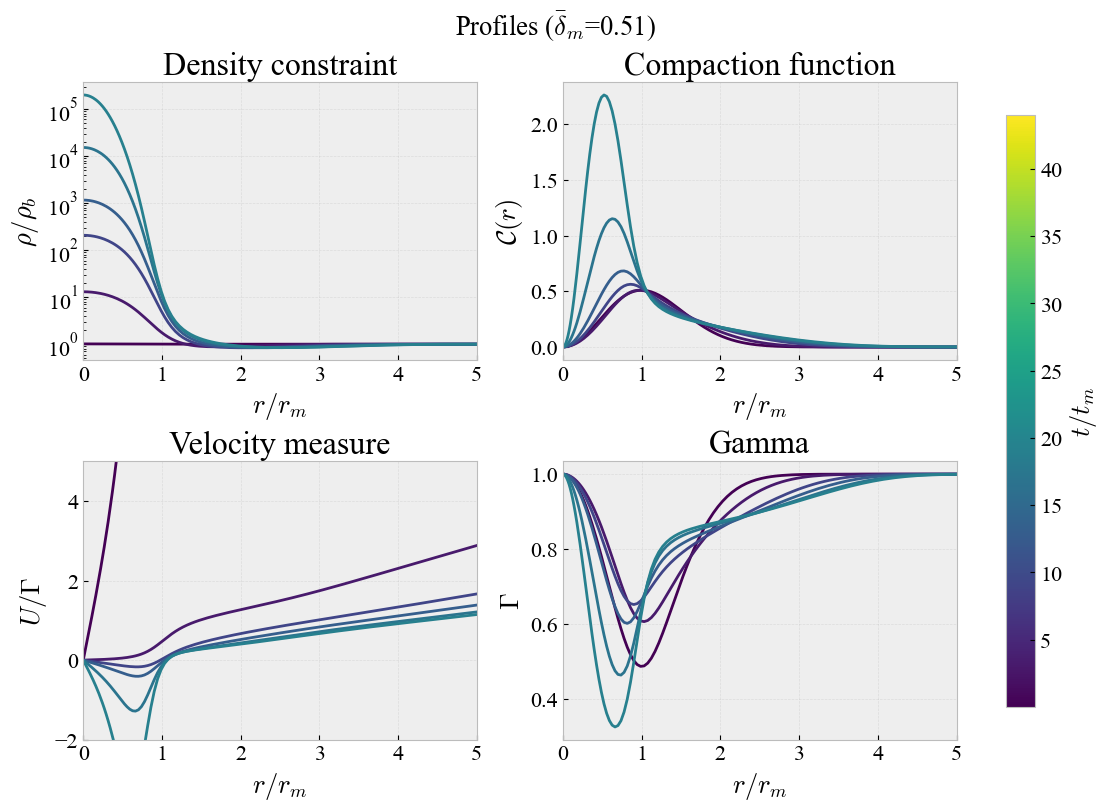

[0.5088757219278354, 0.508658328977657, 0.562396825066901, 0.6823259565573921, 1.1507542830686617, 2.2614676909740856, nan, nan, nan, nan, nan, nan]


In [30]:
"""
Reproducing Figs. 4-6 of:
Albert Escrivà, "Simulation of primordial black hole formation using pseudo-spectral methods"
Physics of the Dark Universe 27 (2020) 100466.
Each figure follows the same 4-panel structure:
Upper left: Analysis of the radius with the density
Upper Right: Analysis of radius with the Compaction Function
Lower Left: Analysis of radius with velocities (U and Gamma)
Lower Right: Analysis of radius with Gamma only

Each figure studies sub-critical, critical and super-critical, around the critical threshold, found numerically.

The formal spectral methods and numerics to determine the value of the critical threshold were taken directly from original SPriBHoS code,
with some notation and labelling changes. Original code has been labelled as such. Graphing code was not included in the published source,
therefore all plotting and graphic code should be assumed as original.

AI resources such as ChatGPT and CoPilot were used for troubleshooting and bug fixes.

"""

from __future__ import annotations
import math
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import seaborn as sns
cmap = sns.color_palette("viridis", as_cmap=True)
pi = math.pi

def chebymatrix(Ncheb,a,b):

	range_cheb = np.arange(0,Ncheb+1)
	x = np.cos(pi*range_cheb/Ncheb)
	t = (a+b)/2.-((a-b)/2.)*x
	carray = np.hstack([2, np.ones(Ncheb-1), 2])*(-1)**np.arange(0,Ncheb+1)
	X = np.tile(x,(Ncheb+1,1))
	dX = X.T - X
	Dp = (carray[:,np.newaxis]*(1.0/carray)[np.newaxis,:])/(dX+(np.identity(Ncheb+1)))       
	Dp = Dp - np.diag(Dp.sum(axis=1))            
	Dcheb =(2./(b-a))*Dp

	return Dcheb, t

def curvature_profile(xf,rmf):
	K = np.exp(-(xf/rmf)**2)
	return K

def derivative_curvature_profile(xf,rmf):
	Kd = -2.*(xf/rmf**2)*np.exp(-(xf/rmf)**2)
	return Kd


def A_versus_threshold_original_style(rm, w, delta_bar_m) :

    fw = 3.0 * (1.0 + w) / (5.0 + 3.0 * w)
    Krm = math.exp(-1.0)  # Gaussian Kbar(rm)=e^{-1}
    return delta_bar_m / (fw * Krm * (rm ** 2))


def A_versus_threshold_general(rm, w, delta_bar_m) :
    fw = 3.0 * (1.0 + w) / (5.0 + 3.0 * w)
    Kbar_rm = math.exp(-(1.0 ) * (1.0 ** (2.0 )))  
    return delta_bar_m / (fw * Kbar_rm * (rm ** 2))


@dataclass
class SimParams:
    w: float = 1.0 / 3.0
    t0: float = 1.0
    a0: float = 1.0
    Nh: int = 90
    rm_N: float = 10.0          
    dt0: float = 1e-3
    Ncheb: int = 200
    t_final: float = 80000      
    use_general_q: bool = False
   
C_list=[]
# Same initial conditions, just defined as a class instead
class PBHSimulator:
    def __init__(self, p: SimParams):
        self.p = p
        self.alpha = 2.0 / (3.0 * (1.0 + p.w))  
        self.H0 = self.alpha / p.t0
        self.RH0 = 1.0 / self.H0
        self.eb0 = (3.0 / (8.0 * pi)) * (self.H0 ** 2)

        self.rmin = 0.0
        self.rmax = p.Nh * self.RH0

        # Chebyshev grid + D
        self.D, self.r = chebymatrix(p.Ncheb, self.rmin, self.rmax)
        self.ones = np.ones(p.Ncheb + 1, dtype=np.float64)

        #Previously defined within epsilon horizon crossing
        self.rm = p.rm_N * self.RH0
        self.tm = p.t0 * (p.rm_N ** 2)

  
    def energy_FRW(self, t) :
        return self.ones * self.eb0 * (self.p.t0 / t) ** 2

    def solution_FRW(self, t) :
        a = self.p.a0 * (t / self.p.t0) ** self.alpha   #scale factor
        H = self.alpha / t                              #Hubble Factor
        e = self.energy_FRW(t)                          #Energy density of the background
        R = a * self.r                                  #Areal Radius
        U = R * H                                       #Euler Velocity
        M = (4.0 * pi / 3.0) * e * R ** 3               #Mass of Background
        A = 1.0 * self.ones                             #Lapse Function
        G = 1.0 * self.ones                             #Gamma Function
        return e, R, U, M, A, G

    def initial_perturbation_magnitudes(self, K, Kp) :
        w = self.p.w
        dek = (3.0 * (1.0 + w) / (5.0 + 3.0 * w)) * (K + (self.r / 3.0) * Kp) * (self.rm ** 2)
        dUk = -(1.0 / (5.0 + 3.0 * w)) * K * (self.rm ** 2)
        dAk = -(w / (1.0 + w)) * dek
        dMk = -3.0 * (1.0 + w) * dUk
        dRk = -dek * w / ((1.0 + 3.0 * w) * (1.0 + w)) + dUk / (1.0 + 3.0 * w)
        return dek, dUk, dAk, dMk, dRk

    def epsilon_horizon_crossing(self):
        eps = 1.0 / (self.p.a0 * self.H0 * self.rm)
        tH = self.tm
        return eps, tH

    #called x_Ikk in source code
    def initial_conditions(self, eps, dek, dRk, dUk, dAk, dMk):
        eI = self.eb0 * (self.ones + dek * (eps ** 2))
        aI = self.p.a0
        RI = aI * self.r * (self.ones + dRk * (eps ** 2))
        UI = self.H0 * RI * (self.ones + dUk * (eps ** 2))
        AI = self.ones + dAk * (eps ** 2)
        MI = (4.0 * pi / 3.0) * self.eb0 * (self.ones + dMk * (eps ** 2)) * RI ** 3
        frac = MI[:-1] / RI[:-1]
        frac = np.insert(frac, len(frac), 0.0)
        GI = np.sqrt(self.ones + UI ** 2 - 2.0 * frac)
        return eI, RI, UI, AI, MI, GI

    def derivs(self, e, U, R) :
        de = np.dot(self.D,e)
        dU = np.dot(self.D,U)
        dR = np.dot(self.D,R)
        return de, dU, dR

    def system_static(self, e, M, R, U, eFRW):
        w = self.p.w
        A = (eFRW / e) ** (w / (w + 1.0))
        frac = M[:-1] / R[:-1]
        frac = np.insert(frac, len(frac), 0.0)

        arg = 1.0 + U**2 - 2.0 * frac

        # numerical guard: avoid tiny negative values from roundoff
        arg = np.maximum(arg, 0.0)

        G = np.sqrt(arg)
        return A, G

    #compiling excision functions from source code
    def RK_excision(self, U, R, M, A, G, e, de, dR, dU) :
        w = self.p.w
        frac = M[:-1] / (R[:-1] ** 2)
        frac = np.insert(frac, len(frac), 0.0)
        Ut = -A * (4.0 * pi * R * w * e + frac + (w / (1.0 + w)) * (de * G ** 2) / (e * dR))
        Rt = U * A
        Mt = -A * 4.0 * pi * w * e * U * (R ** 2)

        derU_R = dU / dR
        ratioUR = U[:-1] / R[:-1]
        ratioUR = np.insert(ratioUR, len(ratioUR), derU_R[-1])
        et = -A * e * (1.0 + w) * (2.0 * ratioUR + dU / dR)
        return Ut, Rt, Mt, et
    
    #compiling computation executing the solving, where stages represent different functions in source code
    def computation_excision(self, t, dt, U, R, M, A, G, e):
        # stage 1
        de1, dU1, dR1 = self.derivs(e, U, R)
        de1[0] = 0.0
        de1[-1] = 0.0
        k1U, k1R, k1M, k1e = self.RK_excision(U, R, M, A, G, e, de1, dR1, dU1)

        # stage 2
        e2 = e + 0.5 * dt * k1e
        U2 = U + 0.5 * dt * k1U
        R2 = R + 0.5 * dt * k1R
        M2 = M + 0.5 * dt * k1M
        U2[-1] = R2[-1] = M2[-1] = 0.0

        eFRW2 = self.energy_FRW(t + 0.5 * dt - dt)
        A2, G2 = self.system_static(e2, M2, R2, U2, eFRW2)
        de2, dU2, dR2 = self.derivs(e2, U2, R2)
        de2[0] = 0.0
        de2[-1] = 0.0
        k2U, k2R, k2M, k2e = self.RK_excision(U2, R2, M2, A2, G2, e2, de2, dR2, dU2)

        # stage 3
        e3 = e + 0.5 * dt * k2e
        U3 = U + 0.5 * dt * k2U
        R3 = R + 0.5 * dt * k2R
        M3 = M + 0.5 * dt * k2M
        U3[-1] = R3[-1] = M3[-1] = 0.0

        eFRW3 = self.energy_FRW(t + 0.5 * dt - dt)
        A3, G3 = self.system_static(e3, M3, R3, U3, eFRW3)
        de3, dU3, dR3 = self.derivs(e3, U3, R3)
        de3[0] = 0.0
        de3[-1] = 0.0
        k3U, k3R, k3M, k3e = self.RK_excision(U3, R3, M3, A3, G3, e3, de3, dR3, dU3)

        # stage 4
        e4 = e + dt * k3e
        U4 = U + dt * k3U
        R4 = R + dt * k3R
        M4 = M + dt * k3M
        U4[-1] = R4[-1] = M4[-1] = 0.0

        eFRW4 = self.energy_FRW(t + dt - dt)
        A4, G4 = self.system_static(e4, M4, R4, U4, eFRW4)
        de4, dU4, dR4 = self.derivs(e4, U4, R4)
        de4[0] = 0.0
        de4[-1] = 0.0
        k4U, k4R, k4M, k4e = self.RK_excision(U4, R4, M4, A4, G4, e4, de4, dR4, dU4)

        # combine
        Unew = U + (dt / 6.0) * (k1U + 2 * k2U + 2 * k3U + k4U)
        Rnew = R + (dt / 6.0) * (k1R + 2 * k2R + 2 * k3R + k4R)
        Mnew = M + (dt / 6.0) * (k1M + 2 * k2M + 2 * k3M + k4M)
        enew = e + (dt / 6.0) * (k1e + 2 * k2e + 2 * k3e + k4e)

        Unew[-1] = 0.0
        Rnew[-1] = 0.0
        Mnew[-1] = 0.0

        eFRW = self.energy_FRW(t + dt)
        Anew, Gnew = self.system_static(enew, Mnew, Rnew, Unew, eFRW)
        return Unew, Rnew, Mnew, enew, Anew, Gnew, eFRW

    #Redefined in a simpler way
    def compaction(self, M, R, eFRW ) :
        C = 2.0 * (M[:-1] - (4.0 / 3.0) * pi * eFRW[:-1] * (R[:-1] ** 3)) / R[:-1]
        
        C = np.insert(C, -1, 0.0)
        return C

    def build_initial_state(self, delta_bar_m) :
        eps, _ = self.epsilon_horizon_crossing()

      
        Kbar = curvature_profile(self.r, self.rm)
        Kbar_d = derivative_curvature_profile(self.r, self.rm)
        Aamp = A_versus_threshold_general(self.rm, self.p.w, delta_bar_m)
        
        K = Aamp * Kbar
        Kd = Aamp * Kbar_d

        dek, dUk, dAk, dMk, dRk = self.initial_perturbation_magnitudes(K, Kd)
        eI, RI, UI, AI, MI, GI = self.initial_conditions(eps, dek, dRk, dUk, dAk, dMk)
        return eI, RI, UI, AI, MI, GI
    #this involves original definitions for plotting purposes
    def evolve_snapshots(self, delta_bar_m, snapshot_times_over_tm,t_stop_over_tm: Optional[float] = None):
      
        e, R, U, A, M, G = self.build_initial_state(delta_bar_m)
        t = self.p.t0

        snapshot_times_over_tm = sorted(snapshot_times_over_tm)
        targets = [tau * self.tm for tau in snapshot_times_over_tm]
        target_idx = 0

        out: Dict[float, Dict[str, np.ndarray]] = {}
        eps, tH = self.epsilon_horizon_crossing()

        # stop time
        if t_stop_over_tm is None:
            t_stop = targets[-1]
        else:
            t_stop = t_stop_over_tm * self.tm

        # main loop
        while t < t_stop and target_idx < len(targets):
            dt = self.p.dt0 * math.sqrt(t)
            t_next = t + dt

            U, R, M, e, A, G, eFRW = self.computation_excision(t, dt, U, R, M, A, G, e)
            t = t_next

            while target_idx < len(targets) and t >= targets[target_idx]:
              
                tau = snapshot_times_over_tm[target_idx]

                # quantities used in Figs 4–6 
                # rho/rho_b
                rho_ratio = e / eFRW

                # compaction C
                C = self.compaction(M, R, eFRW)
                C_list.append(max(C))
                Gamma = G.copy()

                # U/Gamma 
                with np.errstate(divide="ignore", invalid="ignore"):
                    U_over_Gamma = np.where(Gamma != 0.0, U / Gamma, 0.0)

                # store
                r_over_rm = self.r / self.rm

                out[tau] = {
                    "r": self.r.copy(),
                    "rm": np.array([self.rm], dtype=float),
                    "r_over_rm": r_over_rm.copy(),

                    "R": R.copy(),
                    "U": U.copy(),
                    "M": M.copy(),
                    "A": A.copy(),
                    "Gamma": Gamma,
                    "rho": e.copy(),
                    "rho_FRW": eFRW.copy(),
                    "rho_ratio": rho_ratio,
                    "C": C,
                    "U_over_Gamma": U_over_Gamma,
                    "t": np.array([t], dtype=float),
                    "t_over_tm": np.array([t / self.tm], dtype=float),
                    }


                target_idx += 1

        return out


def _paper_axes_style(ax: plt.Axes, xlabel, ylabel, title):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.grid(True, alpha=0.3)

def plot_fig4_profiles(
    snapshots,
    *,
    delta_bar_m,
    savepath: Optional[str] = None,
):

    taus = sorted(snapshots.keys())

    fig, axs = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

    norm = plt.Normalize(vmin=min(taus), vmax=max(taus))

    for tau in taus:
        d = snapshots[tau]
        x = d["r_over_rm"]
        order = np.argsort(x)
        x = x[order]

        color = cmap(norm(tau))   # color by time

        axs[0, 0].semilogy(x, d["rho_ratio"][order], color=color)
        axs[0, 1].plot(x, d["C"][order], color=color)
        axs[1, 0].plot(x, d["U_over_Gamma"][order], color=color)
        axs[1, 1].plot(x, d["Gamma"][order], color=color)

        for ax in axs.flat:
            ax.set_xlim(0,5)
        axs[1,0].set_ylim(-2, 5)

    _paper_axes_style(axs[0, 0], r"$r/r_m$", r"$\rho/\rho_b$", "Density constraint")
    _paper_axes_style(axs[0, 1], r"$r/r_m$", r"$\mathcal{C}(r)$", "Compaction function")
    _paper_axes_style(axs[1, 0], r"$r/r_m$", r"$U/\Gamma$", "Velocity measure")
    _paper_axes_style(axs[1, 1], r"$r/r_m$", r"$\Gamma$", r"Gamma")

    # Add colorbar 
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axs, shrink=0.9)
    cbar.set_label(r"$t/t_m$")

    fig.suptitle(rf"Profiles ($\bar\delta_m$={delta_bar_m})")

    if savepath:
        fig.savefig(savepath, dpi=200)
    plt.show()

def main():
    p = SimParams(
        w=1.0 / 3.0,
        t0=1.0,
        a0=1.0,
        Nh=90,
        rm_N=10.0,
        dt0=1e-3,
        Ncheb=200,          # paper uses high N for these figs
        t_final=8.0e4,
        use_general_q=False,
   
    
    )

    sim = PBHSimulator(p)
  
    delta_vals = [0.51]

    # Snapshot times t/tm
    snapshot_taus = [0.01,3,9,13,17,19,24,27,32,38,40,44]


    for delta_bar_m in delta_vals:
       
        snaps = sim.evolve_snapshots(delta_bar_m=delta_bar_m, snapshot_times_over_tm=snapshot_taus)
        plot_fig4_profiles(snaps, delta_bar_m=delta_bar_m)


if __name__ == "__main__":
    main()

print(C_list)


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def animate_compaction(
    sim,
    *,
    delta_sub: float,
    delta_super: float,
    tau_start: float = 0.5,
    tau_end: float = 25.0,
    nframes: int = 180,
    xlim=(0, 5),
    ylim=None,                 #
    fps: int = 30,
    save_path: str | None = None,   # "compaction.mp4" or "compaction.gif"
):

    taus = np.linspace(tau_start, tau_end, nframes).tolist()


    snaps_sub = sim.evolve_snapshots(delta_bar_m=delta_sub, snapshot_times_over_tm=taus)
    snaps_sup = sim.evolve_snapshots(delta_bar_m=delta_super, snapshot_times_over_tm=taus)

    # set up figure
    fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
    ax.set_xlabel(r"$r/r_m$")
    ax.set_ylabel(r"$\mathcal{C}(r)$")
    ax.set_title("Compaction function (sub vs super critical)")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    # initialize 
    (line_sub,) = ax.plot([], [], lw=2, label=fr"sub: $\bar\delta_m$={delta_sub}")
    (line_sup,) = ax.plot([], [], lw=2, label=fr"super: $\bar\delta_m$={delta_super}")
    time_text = ax.text(0.02, 0.98, "", transform=ax.transAxes, va="top")
    ax.legend(loc="upper right")

    if ylim is None:
        cmax = 0.0
        for tau in (taus[0], taus[len(taus)//2], taus[-1]):
            cmax = max(cmax,
                       np.nanmax(snaps_sub[tau]["C"]),
                       np.nanmax(snaps_sup[tau]["C"]))
        ax.set_ylim(-0.05 * cmax, 1.05 * cmax)

    # frame update
    def update(i: int):
        tau = taus[i]

        dsub = snaps_sub[tau]
        dsup = snaps_sup[tau]

        x_sub = dsub["r_over_rm"]
        c_sub = dsub["C"]
        x_sup = dsup["r_over_rm"]
        c_sup = dsup["C"]

        osub = np.argsort(x_sub)
        osup = np.argsort(x_sup)

        line_sub.set_data(x_sub[osub], c_sub[osub])
        line_sup.set_data(x_sup[osup], c_sup[osup])

        time_text.set_text(fr"$t/t_m$ = {tau:.3f}")
        return line_sub, line_sup, time_text

    ani = FuncAnimation(fig, update, frames=nframes, interval=1000/fps, blit=True)

    if save_path:
        
        if save_path.lower().endswith(".mp4"):
            ani.save(save_path, fps=fps, dpi=180)
        elif save_path.lower().endswith(".gif"):
            ani.save(save_path, fps=fps, dpi=180, writer="pillow")
        else:
            raise ValueError("save_path must end with .mp4 or .gif")

    plt.show()
    ani.save("/Users/Megan/Desktop/compaction2.mp4", writer="ffmpeg", dpi=180)
    return ani

/var/folders/hk/kt8z304n2n11x6tfqk2bmsmw0000gp/T/ipykernel_30955/1560034037.py:150: RuntimeWarning: invalid value encountered in power
  A = (eFRW / e) ** (w / (w + 1.0))


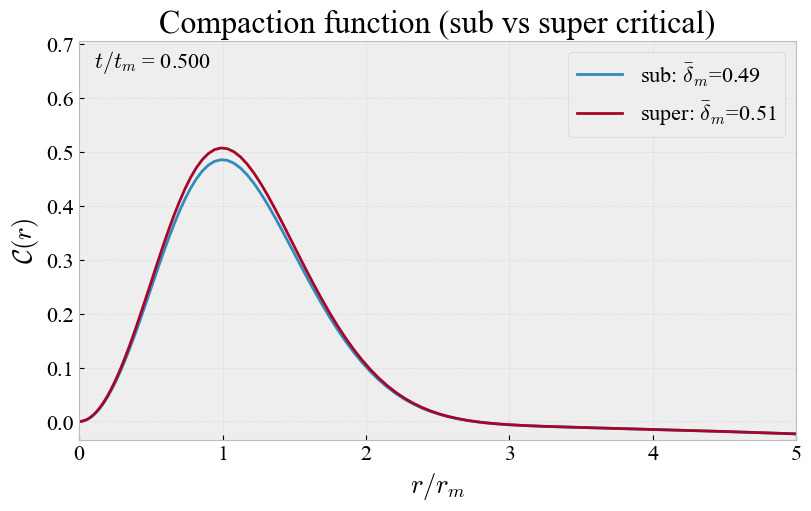

In [32]:
def main():
    p = SimParams(
        w=1.0/3.0,
        t0=1.0,
        a0=1.0,
        Nh=90,
        rm_N=10.0,
        dt0=1e-3,
        Ncheb=200,
        t_final=8.0e4,
    )
    sim = PBHSimulator(p)

    # pick one sub and one super
    animate_compaction(
        sim,
        delta_sub=0.49,
        delta_super=0.51,
        tau_start=0.5,
        tau_end=25.0,
        nframes=240,
        fps=30,
        xlim=(0, 5),
        save_path=None, 
    )
    
if __name__ == "__main__":
    main()


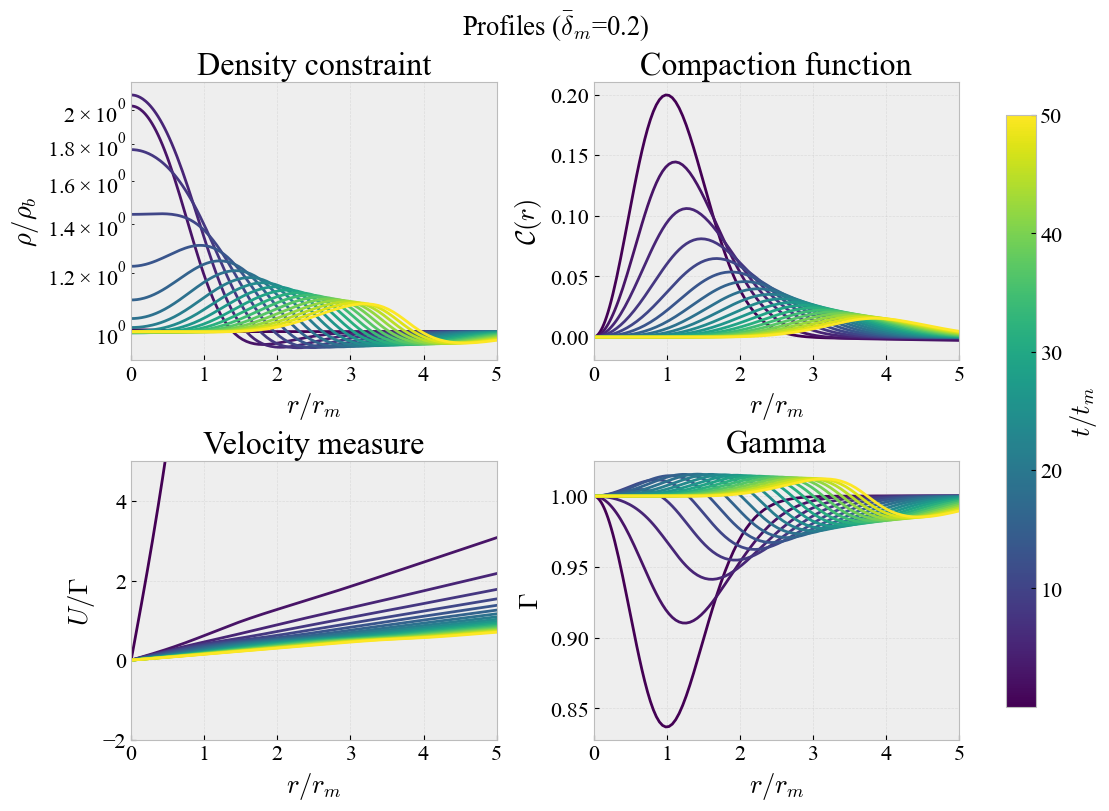

Saved compaction3sub.mp4 (10 s)
[0.19972358848420518, 0.14446001789238247, 0.1060636414051313, 0.08109302557027862, 0.0648071792966928, 0.05367855904527681, 0.04576710044636845, 0.039833881445607774, 0.03523172852937564, 0.03160924719380135, 0.028626917847570422, 0.026148536508147253, 0.024083396786542303, 0.022310776180365893, 0.02077938329560576, 0.019461051354082517, 0.018294211907498616, 0.017241971985872556, 0.016319304674539556, 0.015488250512436547]


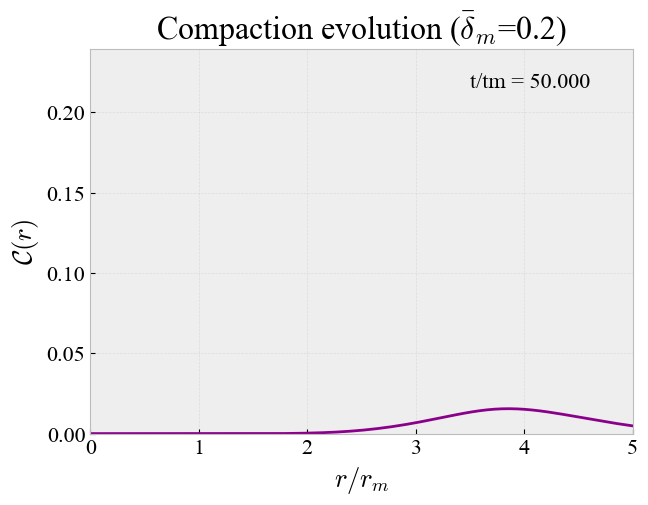

In [33]:
from matplotlib.animation import FuncAnimation, FFMpegWriter

def animate_compaction(snapshots, delta_bar_m, filename="compaction.mp4", duration=9):
    taus = sorted(snapshots.keys())
    nframes = len(taus)
    fps = nframes / duration   

    fig, ax = plt.subplots(figsize=(7,5))
    line, = ax.plot([], [], lw=2, color='darkmagenta')
    time_text = ax.text(0.7, 0.9, "", transform=ax.transAxes)

    ax.set_xlim(0,5)
    ax.set_ylim(0, np.max([np.max(snapshots[t]["C"]) for t in taus])*1.2)
    ax.set_xlabel(r"$r/r_m$")
    ax.set_ylabel(r"$\mathcal{C}(r)$")
    ax.set_title(rf"Compaction evolution ($\bar\delta_m$={delta_bar_m})")
    ax.grid(True, alpha=0.3)

    def update(i):
        tau = taus[i]
        d = snapshots[tau]
        x = d["r_over_rm"]
        C = d["C"]

        order = np.argsort(x)
        line.set_data(x[order], C[order])
        time_text.set_text(f"t/tm = {tau:.3f}")
        return line, time_text

    anim = FuncAnimation(fig, update, frames=nframes, blit=True)

    writer = FFMpegWriter(fps=fps, bitrate=2000)
    anim.save(filename, writer=writer)
    print(f"Saved {filename} ({duration} s)")
    

"""
Reproducing Figs. 4-6 of:
Albert Escrivà, "Simulation of primordial black hole formation using pseudo-spectral methods"
Physics of the Dark Universe 27 (2020) 100466.
Each figure follows the same 4-panel structure:
Upper left: Analysis of the radius with the density
Upper Right: Analysis of radius with the Compaction Function
Lower Left: Analysis of radius with velocities (U and Gamma)
Lower Right: Analysis of radius with Gamma only

Each figure studies sub-critical, critical and super-critical, around the critical threshold, found numerically.

The formal spectral methods and numerics to determine the value of the critical threshold were taken directly from original SPriBHoS code,
with some notation and labelling changes. Original code has been labelled as such. Graphing code was not included in the published source,
therefore all plotting and graphic code should be assumed as original.

AI resources such as ChatGPT and CoPilot were used for troubleshooting and bug fixes.

"""

from __future__ import annotations
import math
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import seaborn as sns
cmap = sns.color_palette("viridis", as_cmap=True)
pi = math.pi

def chebymatrix(Ncheb,a,b):

	range_cheb = np.arange(0,Ncheb+1)
	x = np.cos(pi*range_cheb/Ncheb)
	t = (a+b)/2.-((a-b)/2.)*x
	carray = np.hstack([2, np.ones(Ncheb-1), 2])*(-1)**np.arange(0,Ncheb+1)
	X = np.tile(x,(Ncheb+1,1))
	dX = X.T - X
	Dp = (carray[:,np.newaxis]*(1.0/carray)[np.newaxis,:])/(dX+(np.identity(Ncheb+1)))       
	Dp = Dp - np.diag(Dp.sum(axis=1))            
	Dcheb =(2./(b-a))*Dp

	return Dcheb, t

def curvature_profile(xf,rmf):
	K = np.exp(-(xf/rmf)**2)
	return K

def derivative_curvature_profile(xf,rmf):
	Kd = -2.*(xf/rmf**2)*np.exp(-(xf/rmf)**2)
	return Kd


def A_versus_threshold_original_style(rm, w, delta_bar_m) :

    fw = 3.0 * (1.0 + w) / (5.0 + 3.0 * w)
    Krm = math.exp(-1.0)  # Gaussian Kbar(rm)=e^{-1}
    return delta_bar_m / (fw * Krm * (rm ** 2))


def A_versus_threshold_general(rm, w, delta_bar_m) :
    fw = 3.0 * (1.0 + w) / (5.0 + 3.0 * w)
    Kbar_rm = math.exp(-(1.0 ) * (1.0 ** (2.0 )))  
    return delta_bar_m / (fw * Kbar_rm * (rm ** 2))


@dataclass
class SimParams:
    w: float = 1.0 / 3.0
    t0: float = 1.0
    a0: float = 1.0
    Nh: int = 90
    rm_N: float = 10.0          
    dt0: float = 1e-3
    Ncheb: int = 200
    t_final: float = 80000      
    use_general_q: bool = False
   
C_list=[]
# Same initial conditions, just defined as a class instead
class PBHSimulator:
    def __init__(self, p: SimParams):
        self.p = p
        self.alpha = 2.0 / (3.0 * (1.0 + p.w))  
        self.H0 = self.alpha / p.t0
        self.RH0 = 1.0 / self.H0
        self.eb0 = (3.0 / (8.0 * pi)) * (self.H0 ** 2)

        self.rmin = 0.0
        self.rmax = p.Nh * self.RH0

        # Chebyshev grid + D
        self.D, self.r = chebymatrix(p.Ncheb, self.rmin, self.rmax)
        self.ones = np.ones(p.Ncheb + 1, dtype=np.float64)

        #Previously defined within epsilon horizon crossing
        self.rm = p.rm_N * self.RH0
        self.tm = p.t0 * (p.rm_N ** 2)

  
    def energy_FRW(self, t) :
        return self.ones * self.eb0 * (self.p.t0 / t) ** 2

    def solution_FRW(self, t) :
        a = self.p.a0 * (t / self.p.t0) ** self.alpha   #scale factor
        H = self.alpha / t                              #Hubble Factor
        e = self.energy_FRW(t)                          #Energy density of the background
        R = a * self.r                                  #Areal Radius
        U = R * H                                       #Euler Velocity
        M = (4.0 * pi / 3.0) * e * R ** 3               #Mass of Background
        A = 1.0 * self.ones                             #Lapse Function
        G = 1.0 * self.ones                             #Gamma Function
        return e, R, U, M, A, G

    def initial_perturbation_magnitudes(self, K, Kp) :
        w = self.p.w
        dek = (3.0 * (1.0 + w) / (5.0 + 3.0 * w)) * (K + (self.r / 3.0) * Kp) * (self.rm ** 2)
        dUk = -(1.0 / (5.0 + 3.0 * w)) * K * (self.rm ** 2)
        dAk = -(w / (1.0 + w)) * dek
        dMk = -3.0 * (1.0 + w) * dUk
        dRk = -dek * w / ((1.0 + 3.0 * w) * (1.0 + w)) + dUk / (1.0 + 3.0 * w)
        return dek, dUk, dAk, dMk, dRk

    def epsilon_horizon_crossing(self):
        eps = 1.0 / (self.p.a0 * self.H0 * self.rm)
        tH = self.tm
        return eps, tH

    #called x_Ikk in source code
    def initial_conditions(self, eps, dek, dRk, dUk, dAk, dMk):
        eI = self.eb0 * (self.ones + dek * (eps ** 2))
        aI = self.p.a0
        RI = aI * self.r * (self.ones + dRk * (eps ** 2))
        UI = self.H0 * RI * (self.ones + dUk * (eps ** 2))
        AI = self.ones + dAk * (eps ** 2)
        MI = (4.0 * pi / 3.0) * self.eb0 * (self.ones + dMk * (eps ** 2)) * RI ** 3
        frac = MI[:-1] / RI[:-1]
        frac = np.insert(frac, len(frac), 0.0)
        GI = np.sqrt(self.ones + UI ** 2 - 2.0 * frac)
        return eI, RI, UI, AI, MI, GI

    def derivs(self, e, U, R) :
        de = np.dot(self.D,e)
        dU = np.dot(self.D,U)
        dR = np.dot(self.D,R)
        return de, dU, dR

    def system_static(self, e, M, R, U, eFRW):
        w = self.p.w
        A = (eFRW / e) ** (w / (w + 1.0))
        frac = M[:-1] / R[:-1]
        frac = np.insert(frac, len(frac), 0.0)

        arg = 1.0 + U**2 - 2.0 * frac

        # numerical guard: avoid tiny negative values from roundoff
        arg = np.maximum(arg, 0.0)

        G = np.sqrt(arg)
        return A, G

    #compiling excision functions from source code
    def RK_excision(self, U, R, M, A, G, e, de, dR, dU) :
        w = self.p.w
        frac = M[:-1] / (R[:-1] ** 2)
        frac = np.insert(frac, len(frac), 0.0)
        Ut = -A * (4.0 * pi * R * w * e + frac + (w / (1.0 + w)) * (de * G ** 2) / (e * dR))
        Rt = U * A
        Mt = -A * 4.0 * pi * w * e * U * (R ** 2)

        derU_R = dU / dR
        ratioUR = U[:-1] / R[:-1]
        ratioUR = np.insert(ratioUR, len(ratioUR), derU_R[-1])
        et = -A * e * (1.0 + w) * (2.0 * ratioUR + dU / dR)
        return Ut, Rt, Mt, et
    
    #compiling computation executing the solving, where stages represent different functions in source code
    def computation_excision(self, t, dt, U, R, M, A, G, e):
        # stage 1
        de1, dU1, dR1 = self.derivs(e, U, R)
        de1[0] = 0.0
        de1[-1] = 0.0
        k1U, k1R, k1M, k1e = self.RK_excision(U, R, M, A, G, e, de1, dR1, dU1)

        # stage 2
        e2 = e + 0.5 * dt * k1e
        U2 = U + 0.5 * dt * k1U
        R2 = R + 0.5 * dt * k1R
        M2 = M + 0.5 * dt * k1M
        U2[-1] = R2[-1] = M2[-1] = 0.0

        eFRW2 = self.energy_FRW(t + 0.5 * dt - dt)
        A2, G2 = self.system_static(e2, M2, R2, U2, eFRW2)
        de2, dU2, dR2 = self.derivs(e2, U2, R2)
        de2[0] = 0.0
        de2[-1] = 0.0
        k2U, k2R, k2M, k2e = self.RK_excision(U2, R2, M2, A2, G2, e2, de2, dR2, dU2)

        # stage 3
        e3 = e + 0.5 * dt * k2e
        U3 = U + 0.5 * dt * k2U
        R3 = R + 0.5 * dt * k2R
        M3 = M + 0.5 * dt * k2M
        U3[-1] = R3[-1] = M3[-1] = 0.0

        eFRW3 = self.energy_FRW(t + 0.5 * dt - dt)
        A3, G3 = self.system_static(e3, M3, R3, U3, eFRW3)
        de3, dU3, dR3 = self.derivs(e3, U3, R3)
        de3[0] = 0.0
        de3[-1] = 0.0
        k3U, k3R, k3M, k3e = self.RK_excision(U3, R3, M3, A3, G3, e3, de3, dR3, dU3)

        # stage 4
        e4 = e + dt * k3e
        U4 = U + dt * k3U
        R4 = R + dt * k3R
        M4 = M + dt * k3M
        U4[-1] = R4[-1] = M4[-1] = 0.0

        eFRW4 = self.energy_FRW(t + dt - dt)
        A4, G4 = self.system_static(e4, M4, R4, U4, eFRW4)
        de4, dU4, dR4 = self.derivs(e4, U4, R4)
        de4[0] = 0.0
        de4[-1] = 0.0
        k4U, k4R, k4M, k4e = self.RK_excision(U4, R4, M4, A4, G4, e4, de4, dR4, dU4)

        # combine
        Unew = U + (dt / 6.0) * (k1U + 2 * k2U + 2 * k3U + k4U)
        Rnew = R + (dt / 6.0) * (k1R + 2 * k2R + 2 * k3R + k4R)
        Mnew = M + (dt / 6.0) * (k1M + 2 * k2M + 2 * k3M + k4M)
        enew = e + (dt / 6.0) * (k1e + 2 * k2e + 2 * k3e + k4e)

        Unew[-1] = 0.0
        Rnew[-1] = 0.0
        Mnew[-1] = 0.0

        eFRW = self.energy_FRW(t + dt)
        Anew, Gnew = self.system_static(enew, Mnew, Rnew, Unew, eFRW)
        return Unew, Rnew, Mnew, enew, Anew, Gnew, eFRW

    #Redefined in a simpler way
    def compaction(self, M, R, eFRW ) :
        C = 2.0 * (M[:-1] - (4.0 / 3.0) * pi * eFRW[:-1] * (R[:-1] ** 3)) / R[:-1]
        
        C = np.insert(C, -1, 0.0)
        return C

    def build_initial_state(self, delta_bar_m) :
        eps, _ = self.epsilon_horizon_crossing()

      
        Kbar = curvature_profile(self.r, self.rm)
        Kbar_d = derivative_curvature_profile(self.r, self.rm)
        Aamp = A_versus_threshold_general(self.rm, self.p.w, delta_bar_m)
        
        K = Aamp * Kbar
        Kd = Aamp * Kbar_d

        dek, dUk, dAk, dMk, dRk = self.initial_perturbation_magnitudes(K, Kd)
        eI, RI, UI, AI, MI, GI = self.initial_conditions(eps, dek, dRk, dUk, dAk, dMk)
        return eI, RI, UI, AI, MI, GI
    #this involves original definitions for plotting purposes
    def evolve_snapshots(self, delta_bar_m, snapshot_times_over_tm,t_stop_over_tm: Optional[float] = None):
      
        e, R, U, A, M, G = self.build_initial_state(delta_bar_m)
        t = self.p.t0

        snapshot_times_over_tm = sorted(snapshot_times_over_tm)
        targets = [tau * self.tm for tau in snapshot_times_over_tm]
        target_idx = 0

        out: Dict[float, Dict[str, np.ndarray]] = {}
        eps, tH = self.epsilon_horizon_crossing()

        # stop time
        if t_stop_over_tm is None:
            t_stop = targets[-1]
        else:
            t_stop = t_stop_over_tm * self.tm

        # main loop
        while t < t_stop and target_idx < len(targets):
            dt = self.p.dt0 * math.sqrt(t)
            t_next = t + dt

            U, R, M, e, A, G, eFRW = self.computation_excision(t, dt, U, R, M, A, G, e)
            t = t_next

            while target_idx < len(targets) and t >= targets[target_idx]:
              
                tau = snapshot_times_over_tm[target_idx]

                # quantities used in Figs 4–6 
                # rho/rho_b
                rho_ratio = e / eFRW

                # compaction C
                C = self.compaction(M, R, eFRW)
                C_list.append(max(C))
                Gamma = G.copy()

                # U/Gamma 
                with np.errstate(divide="ignore", invalid="ignore"):
                    U_over_Gamma = np.where(Gamma != 0.0, U / Gamma, 0.0)

                # store
                r_over_rm = self.r / self.rm

                out[tau] = {
                    "r": self.r.copy(),
                    "rm": np.array([self.rm], dtype=float),
                    "r_over_rm": r_over_rm.copy(),

                    "R": R.copy(),
                    "U": U.copy(),
                    "M": M.copy(),
                    "A": A.copy(),
                    "Gamma": Gamma,
                    "rho": e.copy(),
                    "rho_FRW": eFRW.copy(),
                    "rho_ratio": rho_ratio,
                    "C": C,
                    "U_over_Gamma": U_over_Gamma,
                    "t": np.array([t], dtype=float),
                    "t_over_tm": np.array([t / self.tm], dtype=float),
                    }


                target_idx += 1

        return out


def _paper_axes_style(ax: plt.Axes, xlabel, ylabel, title):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.grid(True, alpha=0.3)

def plot_fig4_profiles(
    snapshots,
    *,
    delta_bar_m,
    savepath: Optional[str] = None,
):

    taus = sorted(snapshots.keys())

    fig, axs = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

    norm = plt.Normalize(vmin=min(taus), vmax=max(taus))

    for tau in taus:
        d = snapshots[tau]
        x = d["r_over_rm"]
        order = np.argsort(x)
        x = x[order]

        color = cmap(norm(tau))   # color by time

        axs[0, 0].semilogy(x, d["rho_ratio"][order], color=color)
        axs[0, 1].plot(x, d["C"][order], color=color)
        axs[1, 0].plot(x, d["U_over_Gamma"][order], color=color)
        axs[1, 1].plot(x, d["Gamma"][order], color=color)

        for ax in axs.flat:
            ax.set_xlim(0,5)
        axs[1,0].set_ylim(-2, 5)

    _paper_axes_style(axs[0, 0], r"$r/r_m$", r"$\rho/\rho_b$", "Density constraint")
    _paper_axes_style(axs[0, 1], r"$r/r_m$", r"$\mathcal{C}(r)$", "Compaction function")
    _paper_axes_style(axs[1, 0], r"$r/r_m$", r"$U/\Gamma$", "Velocity measure")
    _paper_axes_style(axs[1, 1], r"$r/r_m$", r"$\Gamma$", r"Gamma")

    # Add colorbar 
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axs, shrink=0.9)
    cbar.set_label(r"$t/t_m$")

    fig.suptitle(rf"Profiles ($\bar\delta_m$={delta_bar_m})")

    if savepath:
        fig.savefig(savepath, dpi=200)
    plt.show()

def main():
    p = SimParams(
        w=1.0 / 3.0,
        t0=1.0,
        a0=1.0,
        Nh=90,
        rm_N=10.0,
        dt0=1e-3,
        Ncheb=200,          
        t_final=8.0e4,
        use_general_q=False,
   
    
    )

    sim = PBHSimulator(p)
  
    delta_vals = [0.2]

    # Snapshot times t/tm
    snapshot_taus = np.linspace(0.0001,50,20)

    for delta_bar_m in delta_vals:
       
        snaps = sim.evolve_snapshots(delta_bar_m=delta_bar_m, snapshot_times_over_tm=snapshot_taus)
        plot_fig4_profiles(snaps, delta_bar_m=delta_bar_m)

    animate_compaction(snaps, delta_bar_m, filename="compaction3sub.mp4", duration=10)
if __name__ == "__main__":
    main()

print(C_list)


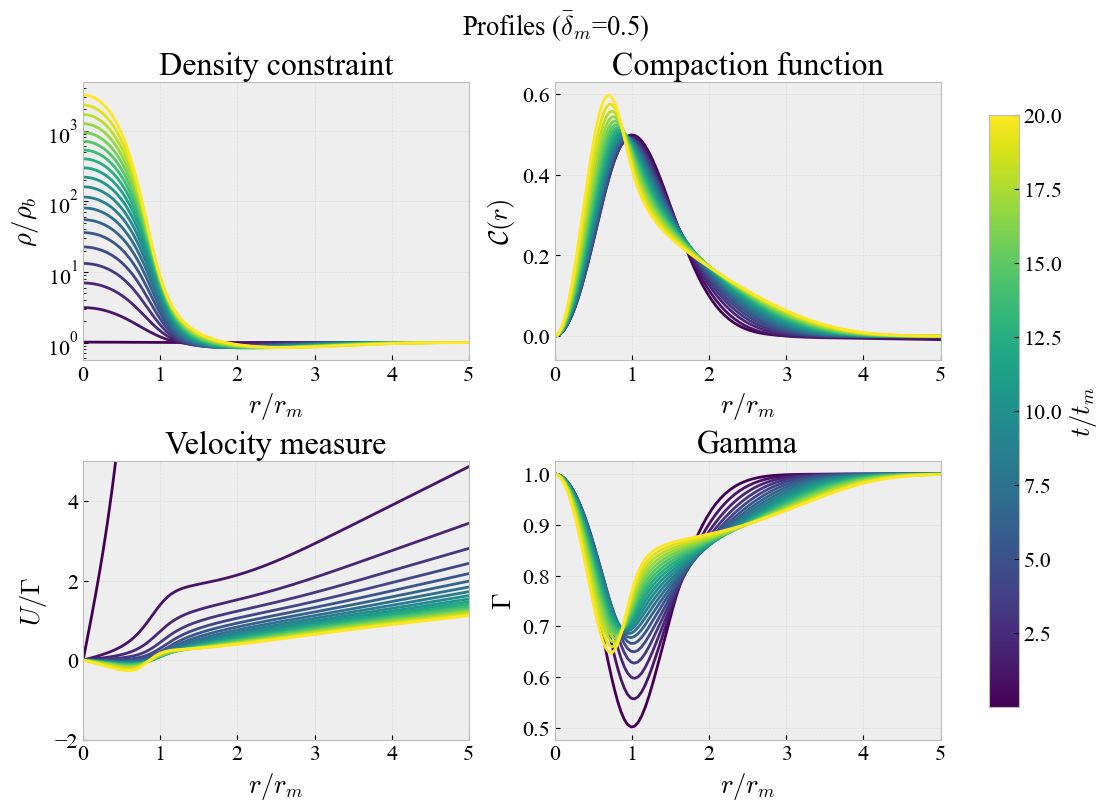

[0.4989134156711977, 0.49522674606395306, 0.4928055253300568, 0.4911819699534128, 0.49091442399616264, 0.4918841702777468, 0.49295273109997506, 0.4947148399081741, 0.4973647829704844, 0.4996817329517197, 0.5031599908634165, 0.5071759385112606, 0.5114049021742206, 0.5177662377031383, 0.5240626092923452, 0.5336354511213265, 0.5438460867000634, 0.5583081227664553, 0.574770111267596, 0.5981352951766321]


In [34]:
from matplotlib.animation import FuncAnimation, FFMpegWriter

def animate_compaction(snapshots, delta_bar_m, filename="compaction.mp4", duration=9):
    taus = sorted(snapshots.keys())
    nframes = len(taus)
    fps = nframes / duration   

    fig, ax = plt.subplots(figsize=(7,5))
    line, = ax.plot([], [], lw=2, color='darkmagenta')
    time_text = ax.text(0.7, 0.9, "", transform=ax.transAxes)

    ax.set_xlim(0,5)
    ax.set_ylim(0, np.max([np.max(snapshots[t]["C"]) for t in taus])*1.2)
    ax.set_xlabel(r"$r/r_m$")
    ax.set_ylabel(r"$\mathcal{C}(r)$")
    ax.set_title(rf"Compaction evolution ($\bar\delta_m$={delta_bar_m})")
    ax.grid(True, alpha=0.3)

    def update(i):
        tau = taus[i]
        d = snapshots[tau]
        x = d["r_over_rm"]
        C = d["C"]

        order = np.argsort(x)
        line.set_data(x[order], C[order])
        time_text.set_text(f"t/tm = {tau:.3f}")
        return line, time_text

    anim = FuncAnimation(fig, update, frames=nframes, blit=True)

    writer = FFMpegWriter(fps=fps, bitrate=2000)
    anim.save(filename, writer=writer)
    print(f"Saved {filename} ({duration} s)")
    

"""
Reproducing Figs. 4-6 of:
Albert Escrivà, "Simulation of primordial black hole formation using pseudo-spectral methods"
Physics of the Dark Universe 27 (2020) 100466.
Each figure follows the same 4-panel structure:
Upper left: Analysis of the radius with the density
Upper Right: Analysis of radius with the Compaction Function
Lower Left: Analysis of radius with velocities (U and Gamma)
Lower Right: Analysis of radius with Gamma only

Each figure studies sub-critical, critical and super-critical, around the critical threshold, found numerically.

The formal spectral methods and numerics to determine the value of the critical threshold were taken directly from original SPriBHoS code,
with some notation and labelling changes. Original code has been labelled as such. Graphing code was not included in the published source,
therefore all plotting and graphic code should be assumed as original.

AI resources such as ChatGPT and CoPilot were used for troubleshooting and bug fixes.

"""

from __future__ import annotations
import math
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import seaborn as sns
cmap = sns.color_palette("viridis", as_cmap=True)
pi = math.pi

def chebymatrix(Ncheb,a,b):

	range_cheb = np.arange(0,Ncheb+1)
	x = np.cos(pi*range_cheb/Ncheb)
	t = (a+b)/2.-((a-b)/2.)*x
	carray = np.hstack([2, np.ones(Ncheb-1), 2])*(-1)**np.arange(0,Ncheb+1)
	X = np.tile(x,(Ncheb+1,1))
	dX = X.T - X
	Dp = (carray[:,np.newaxis]*(1.0/carray)[np.newaxis,:])/(dX+(np.identity(Ncheb+1)))       
	Dp = Dp - np.diag(Dp.sum(axis=1))            
	Dcheb =(2./(b-a))*Dp

	return Dcheb, t

def curvature_profile(xf,rmf):
	K = np.exp(-(xf/rmf)**2)
	return K

def derivative_curvature_profile(xf,rmf):
	Kd = -2.*(xf/rmf**2)*np.exp(-(xf/rmf)**2)
	return Kd


def A_versus_threshold_original_style(rm, w, delta_bar_m) :

    fw = 3.0 * (1.0 + w) / (5.0 + 3.0 * w)
    Krm = math.exp(-1.0)  # Gaussian Kbar(rm)=e^{-1}
    return delta_bar_m / (fw * Krm * (rm ** 2))


def A_versus_threshold_general(rm, w, delta_bar_m) :
    fw = 3.0 * (1.0 + w) / (5.0 + 3.0 * w)
    Kbar_rm = math.exp(-(1.0 ) * (1.0 ** (2.0 )))  
    return delta_bar_m / (fw * Kbar_rm * (rm ** 2))


@dataclass
class SimParams:
    w: float = 1.0 / 3.0
    t0: float = 1.0
    a0: float = 1.0
    Nh: int = 90
    rm_N: float = 10.0          
    dt0: float = 1e-3
    Ncheb: int = 200
    t_final: float = 80000      
    use_general_q: bool = False
   
C_list=[]
# Same initial conditions, just defined as a class instead
class PBHSimulator:
    def __init__(self, p: SimParams):
        self.p = p
        self.alpha = 2.0 / (3.0 * (1.0 + p.w))  
        self.H0 = self.alpha / p.t0
        self.RH0 = 1.0 / self.H0
        self.eb0 = (3.0 / (8.0 * pi)) * (self.H0 ** 2)

        self.rmin = 0.0
        self.rmax = p.Nh * self.RH0

        # Chebyshev grid + D
        self.D, self.r = chebymatrix(p.Ncheb, self.rmin, self.rmax)
        self.ones = np.ones(p.Ncheb + 1, dtype=np.float64)

        #Previously defined within epsilon horizon crossing
        self.rm = p.rm_N * self.RH0
        self.tm = p.t0 * (p.rm_N ** 2)

  
    def energy_FRW(self, t) :
        return self.ones * self.eb0 * (self.p.t0 / t) ** 2

    def solution_FRW(self, t) :
        a = self.p.a0 * (t / self.p.t0) ** self.alpha   #scale factor
        H = self.alpha / t                              #Hubble Factor
        e = self.energy_FRW(t)                          #Energy density of the background
        R = a * self.r                                  #Areal Radius
        U = R * H                                       #Euler Velocity
        M = (4.0 * pi / 3.0) * e * R ** 3               #Mass of Background
        A = 1.0 * self.ones                             #Lapse Function
        G = 1.0 * self.ones                             #Gamma Function
        return e, R, U, M, A, G

    def initial_perturbation_magnitudes(self, K, Kp) :
        w = self.p.w
        dek = (3.0 * (1.0 + w) / (5.0 + 3.0 * w)) * (K + (self.r / 3.0) * Kp) * (self.rm ** 2)
        dUk = -(1.0 / (5.0 + 3.0 * w)) * K * (self.rm ** 2)
        dAk = -(w / (1.0 + w)) * dek
        dMk = -3.0 * (1.0 + w) * dUk
        dRk = -dek * w / ((1.0 + 3.0 * w) * (1.0 + w)) + dUk / (1.0 + 3.0 * w)
        return dek, dUk, dAk, dMk, dRk

    def epsilon_horizon_crossing(self):
        eps = 1.0 / (self.p.a0 * self.H0 * self.rm)
        tH = self.tm
        return eps, tH

    #called x_Ikk in source code
    def initial_conditions(self, eps, dek, dRk, dUk, dAk, dMk):
        eI = self.eb0 * (self.ones + dek * (eps ** 2))
        aI = self.p.a0
        RI = aI * self.r * (self.ones + dRk * (eps ** 2))
        UI = self.H0 * RI * (self.ones + dUk * (eps ** 2))
        AI = self.ones + dAk * (eps ** 2)
        MI = (4.0 * pi / 3.0) * self.eb0 * (self.ones + dMk * (eps ** 2)) * RI ** 3
        frac = MI[:-1] / RI[:-1]
        frac = np.insert(frac, len(frac), 0.0)
        GI = np.sqrt(self.ones + UI ** 2 - 2.0 * frac)
        return eI, RI, UI, AI, MI, GI

    def derivs(self, e, U, R) :
        de = np.dot(self.D,e)
        dU = np.dot(self.D,U)
        dR = np.dot(self.D,R)
        return de, dU, dR

    def system_static(self, e, M, R, U, eFRW):
        w = self.p.w
        A = (eFRW / e) ** (w / (w + 1.0))
        frac = M[:-1] / R[:-1]
        frac = np.insert(frac, len(frac), 0.0)

        arg = 1.0 + U**2 - 2.0 * frac

        # numerical guard: avoid tiny negative values from roundoff
        arg = np.maximum(arg, 0.0)

        G = np.sqrt(arg)
        return A, G

    #compiling excision functions from source code
    def RK_excision(self, U, R, M, A, G, e, de, dR, dU) :
        w = self.p.w
        frac = M[:-1] / (R[:-1] ** 2)
        frac = np.insert(frac, len(frac), 0.0)
        Ut = -A * (4.0 * pi * R * w * e + frac + (w / (1.0 + w)) * (de * G ** 2) / (e * dR))
        Rt = U * A
        Mt = -A * 4.0 * pi * w * e * U * (R ** 2)

        derU_R = dU / dR
        ratioUR = U[:-1] / R[:-1]
        ratioUR = np.insert(ratioUR, len(ratioUR), derU_R[-1])
        et = -A * e * (1.0 + w) * (2.0 * ratioUR + dU / dR)
        return Ut, Rt, Mt, et
    
    #compiling computation executing the solving, where stages represent different functions in source code
    def computation_excision(self, t, dt, U, R, M, A, G, e):
        # stage 1
        de1, dU1, dR1 = self.derivs(e, U, R)
        de1[0] = 0.0
        de1[-1] = 0.0
        k1U, k1R, k1M, k1e = self.RK_excision(U, R, M, A, G, e, de1, dR1, dU1)

        # stage 2
        e2 = e + 0.5 * dt * k1e
        U2 = U + 0.5 * dt * k1U
        R2 = R + 0.5 * dt * k1R
        M2 = M + 0.5 * dt * k1M
        U2[-1] = R2[-1] = M2[-1] = 0.0

        eFRW2 = self.energy_FRW(t + 0.5 * dt - dt)
        A2, G2 = self.system_static(e2, M2, R2, U2, eFRW2)
        de2, dU2, dR2 = self.derivs(e2, U2, R2)
        de2[0] = 0.0
        de2[-1] = 0.0
        k2U, k2R, k2M, k2e = self.RK_excision(U2, R2, M2, A2, G2, e2, de2, dR2, dU2)

        # stage 3
        e3 = e + 0.5 * dt * k2e
        U3 = U + 0.5 * dt * k2U
        R3 = R + 0.5 * dt * k2R
        M3 = M + 0.5 * dt * k2M
        U3[-1] = R3[-1] = M3[-1] = 0.0

        eFRW3 = self.energy_FRW(t + 0.5 * dt - dt)
        A3, G3 = self.system_static(e3, M3, R3, U3, eFRW3)
        de3, dU3, dR3 = self.derivs(e3, U3, R3)
        de3[0] = 0.0
        de3[-1] = 0.0
        k3U, k3R, k3M, k3e = self.RK_excision(U3, R3, M3, A3, G3, e3, de3, dR3, dU3)

        # stage 4
        e4 = e + dt * k3e
        U4 = U + dt * k3U
        R4 = R + dt * k3R
        M4 = M + dt * k3M
        U4[-1] = R4[-1] = M4[-1] = 0.0

        eFRW4 = self.energy_FRW(t + dt - dt)
        A4, G4 = self.system_static(e4, M4, R4, U4, eFRW4)
        de4, dU4, dR4 = self.derivs(e4, U4, R4)
        de4[0] = 0.0
        de4[-1] = 0.0
        k4U, k4R, k4M, k4e = self.RK_excision(U4, R4, M4, A4, G4, e4, de4, dR4, dU4)

        # combine
        Unew = U + (dt / 6.0) * (k1U + 2 * k2U + 2 * k3U + k4U)
        Rnew = R + (dt / 6.0) * (k1R + 2 * k2R + 2 * k3R + k4R)
        Mnew = M + (dt / 6.0) * (k1M + 2 * k2M + 2 * k3M + k4M)
        enew = e + (dt / 6.0) * (k1e + 2 * k2e + 2 * k3e + k4e)

        Unew[-1] = 0.0
        Rnew[-1] = 0.0
        Mnew[-1] = 0.0

        eFRW = self.energy_FRW(t + dt)
        Anew, Gnew = self.system_static(enew, Mnew, Rnew, Unew, eFRW)
        return Unew, Rnew, Mnew, enew, Anew, Gnew, eFRW

    #Redefined in a simpler way
    def compaction(self, M, R, eFRW ) :
        C = 2.0 * (M[:-1] - (4.0 / 3.0) * pi * eFRW[:-1] * (R[:-1] ** 3)) / R[:-1]
        
        C = np.insert(C, -1, 0.0)
        return C

    def build_initial_state(self, delta_bar_m) :
        eps, _ = self.epsilon_horizon_crossing()

      
        Kbar = curvature_profile(self.r, self.rm)
        Kbar_d = derivative_curvature_profile(self.r, self.rm)
        Aamp = A_versus_threshold_general(self.rm, self.p.w, delta_bar_m)
        
        K = Aamp * Kbar
        Kd = Aamp * Kbar_d

        dek, dUk, dAk, dMk, dRk = self.initial_perturbation_magnitudes(K, Kd)
        eI, RI, UI, AI, MI, GI = self.initial_conditions(eps, dek, dRk, dUk, dAk, dMk)
        return eI, RI, UI, AI, MI, GI
    #this involves original definitions for plotting purposes
    def evolve_snapshots(self, delta_bar_m, snapshot_times_over_tm,t_stop_over_tm: Optional[float] = None):
      
        e, R, U, A, M, G = self.build_initial_state(delta_bar_m)
        t = self.p.t0

        snapshot_times_over_tm = sorted(snapshot_times_over_tm)
        targets = [tau * self.tm for tau in snapshot_times_over_tm]
        target_idx = 0

        out: Dict[float, Dict[str, np.ndarray]] = {}
        eps, tH = self.epsilon_horizon_crossing()

        # stop time
        if t_stop_over_tm is None:
            t_stop = targets[-1]
        else:
            t_stop = t_stop_over_tm * self.tm

        # main loop
        while t < t_stop and target_idx < len(targets):
            dt = self.p.dt0 * math.sqrt(t)
            t_next = t + dt

            U, R, M, e, A, G, eFRW = self.computation_excision(t, dt, U, R, M, A, G, e)
            t = t_next

            while target_idx < len(targets) and t >= targets[target_idx]:
              
                tau = snapshot_times_over_tm[target_idx]

                # quantities used in Figs 4–6 
                # rho/rho_b
                rho_ratio = e / eFRW

                # compaction C
                C = self.compaction(M, R, eFRW)
                C_list.append(max(C))
                Gamma = G.copy()

                # U/Gamma 
                with np.errstate(divide="ignore", invalid="ignore"):
                    U_over_Gamma = np.where(Gamma != 0.0, U / Gamma, 0.0)

                # store
                r_over_rm = self.r / self.rm

                out[tau] = {
                    "r": self.r.copy(),
                    "rm": np.array([self.rm], dtype=float),
                    "r_over_rm": r_over_rm.copy(),

                    "R": R.copy(),
                    "U": U.copy(),
                    "M": M.copy(),
                    "A": A.copy(),
                    "Gamma": Gamma,
                    "rho": e.copy(),
                    "rho_FRW": eFRW.copy(),
                    "rho_ratio": rho_ratio,
                    "C": C,
                    "U_over_Gamma": U_over_Gamma,
                    "t": np.array([t], dtype=float),
                    "t_over_tm": np.array([t / self.tm], dtype=float),
                    }


                target_idx += 1

        return out


def _paper_axes_style(ax: plt.Axes, xlabel, ylabel, title):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.grid(True, alpha=0.3)

def plot_fig4_profiles(
    snapshots,
    *,
    delta_bar_m,
    savepath: Optional[str] = None,
):

    taus = sorted(snapshots.keys())

    fig, axs = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

    norm = plt.Normalize(vmin=min(taus), vmax=max(taus))

    for tau in taus:
        d = snapshots[tau]
        x = d["r_over_rm"]
        order = np.argsort(x)
        x = x[order]

        color = cmap(norm(tau))   # color by time

        axs[0, 0].semilogy(x, d["rho_ratio"][order], color=color)
        axs[0, 1].plot(x, d["C"][order], color=color)
        axs[1, 0].plot(x, d["U_over_Gamma"][order], color=color)
        axs[1, 1].plot(x, d["Gamma"][order], color=color)

        for ax in axs.flat:
            ax.set_xlim(0,5)
        axs[1,0].set_ylim(-2, 5)

    _paper_axes_style(axs[0, 0], r"$r/r_m$", r"$\rho/\rho_b$", "Density constraint")
    _paper_axes_style(axs[0, 1], r"$r/r_m$", r"$\mathcal{C}(r)$", "Compaction function")
    _paper_axes_style(axs[1, 0], r"$r/r_m$", r"$U/\Gamma$", "Velocity measure")
    _paper_axes_style(axs[1, 1], r"$r/r_m$", r"$\Gamma$", r"Gamma")

    # Add colorbar 
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axs, shrink=0.9)
    cbar.set_label(r"$t/t_m$")

    fig.suptitle(rf"Profiles ($\bar\delta_m$={delta_bar_m})")

    if savepath:
        fig.savefig(savepath, dpi=200)
    plt.show()

def main():
    p = SimParams(
        w=1.0 / 3.0,
        t0=1.0,
        a0=1.0,
        Nh=90,
        rm_N=10.0,
        dt0=1e-3,
        Ncheb=200,          # paper uses high N for these figs
        t_final=8.0e4,
        use_general_q=False,
   
    
    )

    sim = PBHSimulator(p)
  
    delta_vals = [0.5]

    # Snapshot times t/tm
    snapshot_taus = np.linspace(0.0001,20,20)

    for delta_bar_m in delta_vals:
       
        snaps = sim.evolve_snapshots(delta_bar_m=delta_bar_m, snapshot_times_over_tm=snapshot_taus)
        plot_fig4_profiles(snaps, delta_bar_m=delta_bar_m)

if __name__ == "__main__":
    main()

print(C_list)


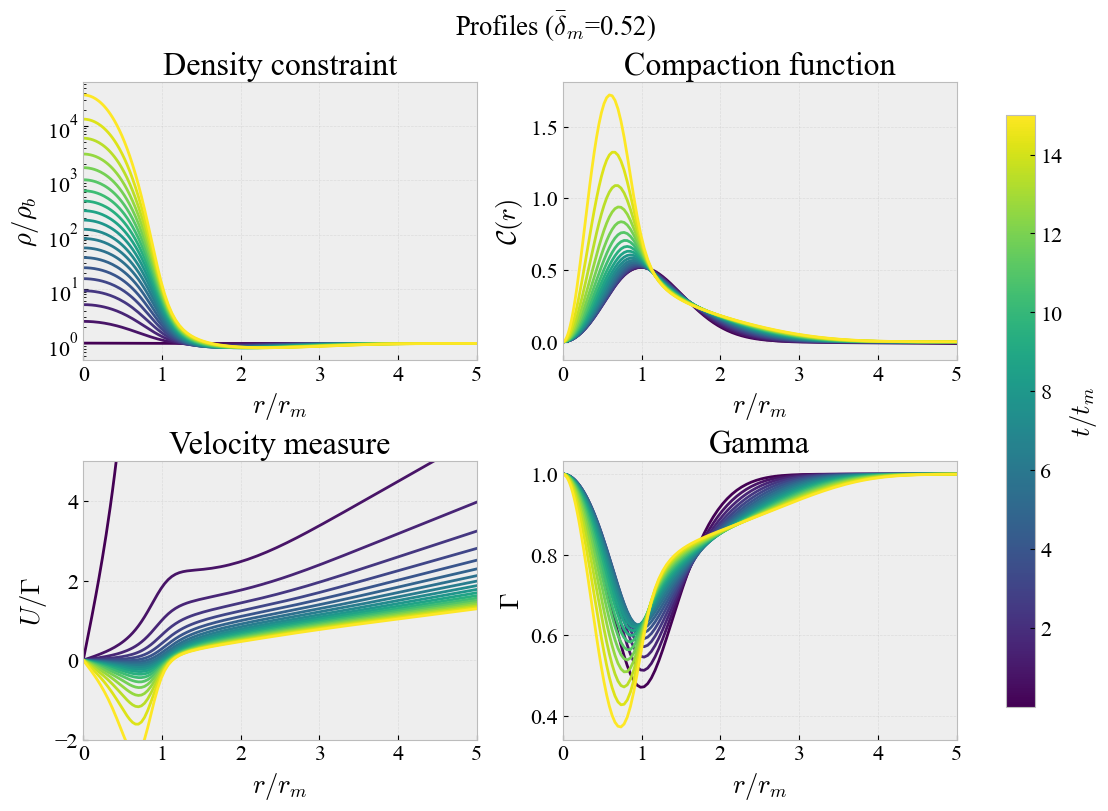

[0.5188373388275815, 0.5190492428058724, 0.5207843498122073, 0.5234776815830559, 0.52794770590651, 0.5347530957686629, 0.5429229352242898, 0.5538621564443107, 0.5676538199543077, 0.5838019985858951, 0.6054559459747462, 0.6305048779293719, 0.6645732108944579, 0.7061099030638596, 0.762130920714924, 0.8367951892499007, 0.9394119724769173, 1.0886157063425024, 1.321187609626801, 1.7205291097081652]


In [35]:
from matplotlib.animation import FuncAnimation, FFMpegWriter

def animate_compaction(snapshots, delta_bar_m, filename="compaction.mp4", duration=9):
    taus = sorted(snapshots.keys())
    nframes = len(taus)
    fps = nframes / duration   # enforce 9 second video

    fig, ax = plt.subplots(figsize=(7,5))
    line, = ax.plot([], [], lw=2, color='darkmagenta')
    time_text = ax.text(0.7, 0.9, "", transform=ax.transAxes)

    ax.set_xlim(0,5)
    ax.set_ylim(0, np.max([np.max(snapshots[t]["C"]) for t in taus])*1.2)
    ax.set_xlabel(r"$r/r_m$")
    ax.set_ylabel(r"$\mathcal{C}(r)$")
    ax.set_title(rf"Compaction evolution ($\bar\delta_m$={delta_bar_m})")
    ax.grid(True, alpha=0.3)

    def update(i):
        tau = taus[i]
        d = snapshots[tau]
        x = d["r_over_rm"]
        C = d["C"]

        order = np.argsort(x)
        line.set_data(x[order], C[order])
        time_text.set_text(f"t/tm = {tau:.3f}")
        return line, time_text

    anim = FuncAnimation(fig, update, frames=nframes, blit=True)

    writer = FFMpegWriter(fps=fps, bitrate=2000)
    anim.save(filename, writer=writer)
    print(f"Saved {filename} ({duration} s)")
    

"""
Reproducing Figs. 4-6 of:
Albert Escrivà, "Simulation of primordial black hole formation using pseudo-spectral methods"
Physics of the Dark Universe 27 (2020) 100466.
Each figure follows the same 4-panel structure:
Upper left: Analysis of the radius with the density
Upper Right: Analysis of radius with the Compaction Function
Lower Left: Analysis of radius with velocities (U and Gamma)
Lower Right: Analysis of radius with Gamma only

Each figure studies sub-critical, critical and super-critical, around the critical threshold, found numerically.

The formal spectral methods and numerics to determine the value of the critical threshold were taken directly from original SPriBHoS code,
with some notation and labelling changes. Original code has been labelled as such. Graphing code was not included in the published source,
therefore all plotting and graphic code should be assumed as original.

AI resources such as ChatGPT and CoPilot were used for troubleshooting and bug fixes.

"""

from __future__ import annotations
import math
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import seaborn as sns
cmap = sns.color_palette("viridis", as_cmap=True)
pi = math.pi

def chebymatrix(Ncheb,a,b):

	range_cheb = np.arange(0,Ncheb+1)
	x = np.cos(pi*range_cheb/Ncheb)
	t = (a+b)/2.-((a-b)/2.)*x
	carray = np.hstack([2, np.ones(Ncheb-1), 2])*(-1)**np.arange(0,Ncheb+1)
	X = np.tile(x,(Ncheb+1,1))
	dX = X.T - X
	Dp = (carray[:,np.newaxis]*(1.0/carray)[np.newaxis,:])/(dX+(np.identity(Ncheb+1)))       
	Dp = Dp - np.diag(Dp.sum(axis=1))            
	Dcheb =(2./(b-a))*Dp

	return Dcheb, t

def curvature_profile(xf,rmf):
	K = np.exp(-(xf/rmf)**2)
	return K

def derivative_curvature_profile(xf,rmf):
	Kd = -2.*(xf/rmf**2)*np.exp(-(xf/rmf)**2)
	return Kd


def A_versus_threshold_original_style(rm, w, delta_bar_m) :

    fw = 3.0 * (1.0 + w) / (5.0 + 3.0 * w)
    Krm = math.exp(-1.0)  # Gaussian Kbar(rm)=e^{-1}
    return delta_bar_m / (fw * Krm * (rm ** 2))


def A_versus_threshold_general(rm, w, delta_bar_m) :
    fw = 3.0 * (1.0 + w) / (5.0 + 3.0 * w)
    Kbar_rm = math.exp(-(1.0 ) * (1.0 ** (2.0 )))  
    return delta_bar_m / (fw * Kbar_rm * (rm ** 2))


@dataclass
class SimParams:
    w: float = 1.0 / 3.0
    t0: float = 1.0
    a0: float = 1.0
    Nh: int = 90
    rm_N: float = 10.0          
    dt0: float = 1e-3
    Ncheb: int = 200
    t_final: float = 80000      
    use_general_q: bool = False
   
C52_list=[]
# Same initial conditions, just defined as a class instead
class PBHSimulator:
    def __init__(self, p: SimParams):
        self.p = p
        self.alpha = 2.0 / (3.0 * (1.0 + p.w))  
        self.H0 = self.alpha / p.t0
        self.RH0 = 1.0 / self.H0
        self.eb0 = (3.0 / (8.0 * pi)) * (self.H0 ** 2)

        self.rmin = 0.0
        self.rmax = p.Nh * self.RH0

        # Chebyshev grid + D
        self.D, self.r = chebymatrix(p.Ncheb, self.rmin, self.rmax)
        self.ones = np.ones(p.Ncheb + 1, dtype=np.float64)

        #Previously defined within epsilon horizon crossing
        self.rm = p.rm_N * self.RH0
        self.tm = p.t0 * (p.rm_N ** 2)

  
    def energy_FRW(self, t) :
        return self.ones * self.eb0 * (self.p.t0 / t) ** 2

    def solution_FRW(self, t) :
        a = self.p.a0 * (t / self.p.t0) ** self.alpha   #scale factor
        H = self.alpha / t                              #Hubble Factor
        e = self.energy_FRW(t)                          #Energy density of the background
        R = a * self.r                                  #Areal Radius
        U = R * H                                       #Euler Velocity
        M = (4.0 * pi / 3.0) * e * R ** 3               #Mass of Background
        A = 1.0 * self.ones                             #Lapse Function
        G = 1.0 * self.ones                             #Gamma Function
        return e, R, U, M, A, G

    def initial_perturbation_magnitudes(self, K, Kp) :
        w = self.p.w
        dek = (3.0 * (1.0 + w) / (5.0 + 3.0 * w)) * (K + (self.r / 3.0) * Kp) * (self.rm ** 2)
        dUk = -(1.0 / (5.0 + 3.0 * w)) * K * (self.rm ** 2)
        dAk = -(w / (1.0 + w)) * dek
        dMk = -3.0 * (1.0 + w) * dUk
        dRk = -dek * w / ((1.0 + 3.0 * w) * (1.0 + w)) + dUk / (1.0 + 3.0 * w)
        return dek, dUk, dAk, dMk, dRk

    def epsilon_horizon_crossing(self):
        eps = 1.0 / (self.p.a0 * self.H0 * self.rm)
        tH = self.tm
        return eps, tH

    #called x_Ikk in source code
    def initial_conditions(self, eps, dek, dRk, dUk, dAk, dMk):
        eI = self.eb0 * (self.ones + dek * (eps ** 2))
        aI = self.p.a0
        RI = aI * self.r * (self.ones + dRk * (eps ** 2))
        UI = self.H0 * RI * (self.ones + dUk * (eps ** 2))
        AI = self.ones + dAk * (eps ** 2)
        MI = (4.0 * pi / 3.0) * self.eb0 * (self.ones + dMk * (eps ** 2)) * RI ** 3
        frac = MI[:-1] / RI[:-1]
        frac = np.insert(frac, len(frac), 0.0)
        GI = np.sqrt(self.ones + UI ** 2 - 2.0 * frac)
        return eI, RI, UI, AI, MI, GI

    def derivs(self, e, U, R) :
        de = np.dot(self.D,e)
        dU = np.dot(self.D,U)
        dR = np.dot(self.D,R)
        return de, dU, dR

    def system_static(self, e, M, R, U, eFRW):
        w = self.p.w
        A = (eFRW / e) ** (w / (w + 1.0))
        frac = M[:-1] / R[:-1]
        frac = np.insert(frac, len(frac), 0.0)

        arg = 1.0 + U**2 - 2.0 * frac

        # numerical guard: avoid tiny negative values from roundoff
        arg = np.maximum(arg, 0.0)

        G = np.sqrt(arg)
        return A, G

    #compiling excision functions from source code
    def RK_excision(self, U, R, M, A, G, e, de, dR, dU) :
        w = self.p.w
        frac = M[:-1] / (R[:-1] ** 2)
        frac = np.insert(frac, len(frac), 0.0)
        Ut = -A * (4.0 * pi * R * w * e + frac + (w / (1.0 + w)) * (de * G ** 2) / (e * dR))
        Rt = U * A
        Mt = -A * 4.0 * pi * w * e * U * (R ** 2)

        derU_R = dU / dR
        ratioUR = U[:-1] / R[:-1]
        ratioUR = np.insert(ratioUR, len(ratioUR), derU_R[-1])
        et = -A * e * (1.0 + w) * (2.0 * ratioUR + dU / dR)
        return Ut, Rt, Mt, et
    
    #compiling computation executing the solving, where stages represent different functions in source code
    def computation_excision(self, t, dt, U, R, M, A, G, e):
        # stage 1
        de1, dU1, dR1 = self.derivs(e, U, R)
        de1[0] = 0.0
        de1[-1] = 0.0
        k1U, k1R, k1M, k1e = self.RK_excision(U, R, M, A, G, e, de1, dR1, dU1)

        # stage 2
        e2 = e + 0.5 * dt * k1e
        U2 = U + 0.5 * dt * k1U
        R2 = R + 0.5 * dt * k1R
        M2 = M + 0.5 * dt * k1M
        U2[-1] = R2[-1] = M2[-1] = 0.0

        eFRW2 = self.energy_FRW(t + 0.5 * dt - dt)
        A2, G2 = self.system_static(e2, M2, R2, U2, eFRW2)
        de2, dU2, dR2 = self.derivs(e2, U2, R2)
        de2[0] = 0.0
        de2[-1] = 0.0
        k2U, k2R, k2M, k2e = self.RK_excision(U2, R2, M2, A2, G2, e2, de2, dR2, dU2)

        # stage 3
        e3 = e + 0.5 * dt * k2e
        U3 = U + 0.5 * dt * k2U
        R3 = R + 0.5 * dt * k2R
        M3 = M + 0.5 * dt * k2M
        U3[-1] = R3[-1] = M3[-1] = 0.0

        eFRW3 = self.energy_FRW(t + 0.5 * dt - dt)
        A3, G3 = self.system_static(e3, M3, R3, U3, eFRW3)
        de3, dU3, dR3 = self.derivs(e3, U3, R3)
        de3[0] = 0.0
        de3[-1] = 0.0
        k3U, k3R, k3M, k3e = self.RK_excision(U3, R3, M3, A3, G3, e3, de3, dR3, dU3)

        # stage 4
        e4 = e + dt * k3e
        U4 = U + dt * k3U
        R4 = R + dt * k3R
        M4 = M + dt * k3M
        U4[-1] = R4[-1] = M4[-1] = 0.0

        eFRW4 = self.energy_FRW(t + dt - dt)
        A4, G4 = self.system_static(e4, M4, R4, U4, eFRW4)
        de4, dU4, dR4 = self.derivs(e4, U4, R4)
        de4[0] = 0.0
        de4[-1] = 0.0
        k4U, k4R, k4M, k4e = self.RK_excision(U4, R4, M4, A4, G4, e4, de4, dR4, dU4)

        # combine
        Unew = U + (dt / 6.0) * (k1U + 2 * k2U + 2 * k3U + k4U)
        Rnew = R + (dt / 6.0) * (k1R + 2 * k2R + 2 * k3R + k4R)
        Mnew = M + (dt / 6.0) * (k1M + 2 * k2M + 2 * k3M + k4M)
        enew = e + (dt / 6.0) * (k1e + 2 * k2e + 2 * k3e + k4e)

        Unew[-1] = 0.0
        Rnew[-1] = 0.0
        Mnew[-1] = 0.0

        eFRW = self.energy_FRW(t + dt)
        Anew, Gnew = self.system_static(enew, Mnew, Rnew, Unew, eFRW)
        return Unew, Rnew, Mnew, enew, Anew, Gnew, eFRW

    #Redefined in a simpler way
    def compaction(self, M, R, eFRW ) :
        C = 2.0 * (M[:-1] - (4.0 / 3.0) * pi * eFRW[:-1] * (R[:-1] ** 3)) / R[:-1]
        
        C = np.insert(C, -1, 0.0)
        return C

    def build_initial_state(self, delta_bar_m) :
        eps, _ = self.epsilon_horizon_crossing()

      
        Kbar = curvature_profile(self.r, self.rm)
        Kbar_d = derivative_curvature_profile(self.r, self.rm)
        Aamp = A_versus_threshold_general(self.rm, self.p.w, delta_bar_m)
        
        K = Aamp * Kbar
        Kd = Aamp * Kbar_d

        dek, dUk, dAk, dMk, dRk = self.initial_perturbation_magnitudes(K, Kd)
        eI, RI, UI, AI, MI, GI = self.initial_conditions(eps, dek, dRk, dUk, dAk, dMk)
        return eI, RI, UI, AI, MI, GI
    #this involves original definitions for plotting purposes
    def evolve_snapshots(self, delta_bar_m, snapshot_times_over_tm,t_stop_over_tm: Optional[float] = None):
      
        e, R, U, A, M, G = self.build_initial_state(delta_bar_m)
        t = self.p.t0

        snapshot_times_over_tm = sorted(snapshot_times_over_tm)
        targets = [tau * self.tm for tau in snapshot_times_over_tm]
        target_idx = 0

        out: Dict[float, Dict[str, np.ndarray]] = {}
        eps, tH = self.epsilon_horizon_crossing()

        # stop time
        if t_stop_over_tm is None:
            t_stop = targets[-1]
        else:
            t_stop = t_stop_over_tm * self.tm

        # main loop
        while t < t_stop and target_idx < len(targets):
            dt = self.p.dt0 * math.sqrt(t)
            t_next = t + dt

            U, R, M, e, A, G, eFRW = self.computation_excision(t, dt, U, R, M, A, G, e)
            t = t_next

            while target_idx < len(targets) and t >= targets[target_idx]:
              
                tau = snapshot_times_over_tm[target_idx]

                # quantities used in Figs 4–6 
                # rho/rho_b
                rho_ratio = e / eFRW

                # compaction C
                C = self.compaction(M, R, eFRW)
                C52_list.append(max(C))
                Gamma = G.copy()

                # U/Gamma 
                with np.errstate(divide="ignore", invalid="ignore"):
                    U_over_Gamma = np.where(Gamma != 0.0, U / Gamma, 0.0)

                # store
                r_over_rm = self.r / self.rm

                out[tau] = {
                    "r": self.r.copy(),
                    "rm": np.array([self.rm], dtype=float),
                    "r_over_rm": r_over_rm.copy(),

                    "R": R.copy(),
                    "U": U.copy(),
                    "M": M.copy(),
                    "A": A.copy(),
                    "Gamma": Gamma,
                    "rho": e.copy(),
                    "rho_FRW": eFRW.copy(),
                    "rho_ratio": rho_ratio,
                    "C": C,
                    "U_over_Gamma": U_over_Gamma,
                    "t": np.array([t], dtype=float),
                    "t_over_tm": np.array([t / self.tm], dtype=float),
                    }


                target_idx += 1

        return out


def _paper_axes_style(ax: plt.Axes, xlabel, ylabel, title):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.grid(True, alpha=0.3)

def plot_fig4_profiles(
    snapshots,
    *,
    delta_bar_m,
    savepath: Optional[str] = None,
):

    taus = sorted(snapshots.keys())

    fig, axs = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

    norm = plt.Normalize(vmin=min(taus), vmax=max(taus))

    for tau in taus:
        d = snapshots[tau]
        x = d["r_over_rm"]
        order = np.argsort(x)
        x = x[order]

        color = cmap(norm(tau))   # color by time

        axs[0, 0].semilogy(x, d["rho_ratio"][order], color=color)
        axs[0, 1].plot(x, d["C"][order], color=color)
        axs[1, 0].plot(x, d["U_over_Gamma"][order], color=color)
        axs[1, 1].plot(x, d["Gamma"][order], color=color)

        for ax in axs.flat:
            ax.set_xlim(0,5)
        axs[1,0].set_ylim(-2, 5)

    _paper_axes_style(axs[0, 0], r"$r/r_m$", r"$\rho/\rho_b$", "Density constraint")
    _paper_axes_style(axs[0, 1], r"$r/r_m$", r"$\mathcal{C}(r)$", "Compaction function")
    _paper_axes_style(axs[1, 0], r"$r/r_m$", r"$U/\Gamma$", "Velocity measure")
    _paper_axes_style(axs[1, 1], r"$r/r_m$", r"$\Gamma$", r"Gamma")

    # Add colorbar 
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axs, shrink=0.9)
    cbar.set_label(r"$t/t_m$")

    fig.suptitle(rf"Profiles ($\bar\delta_m$={delta_bar_m})")

    if savepath:
        fig.savefig(savepath, dpi=200)
    plt.show()

def main():
    p = SimParams(
        w=1.0 / 3.0,
        t0=1.0,
        a0=1.0,
        Nh=90,
        rm_N=10.0,
        dt0=1e-3,
        Ncheb=200,          # paper uses high N for these figs
        t_final=8.0e4,
        use_general_q=False,
   
    
    )

    sim = PBHSimulator(p)
  
    delta_vals = [0.52]

    # Snapshot times t/tm
    snapshot_taus = np.linspace(0.0001,15,20)

    for delta_bar_m in delta_vals:
       
        snaps = sim.evolve_snapshots(delta_bar_m=delta_bar_m, snapshot_times_over_tm=snapshot_taus)
        plot_fig4_profiles(snaps, delta_bar_m=delta_bar_m)

if __name__ == "__main__":
    main()

print(C52_list)


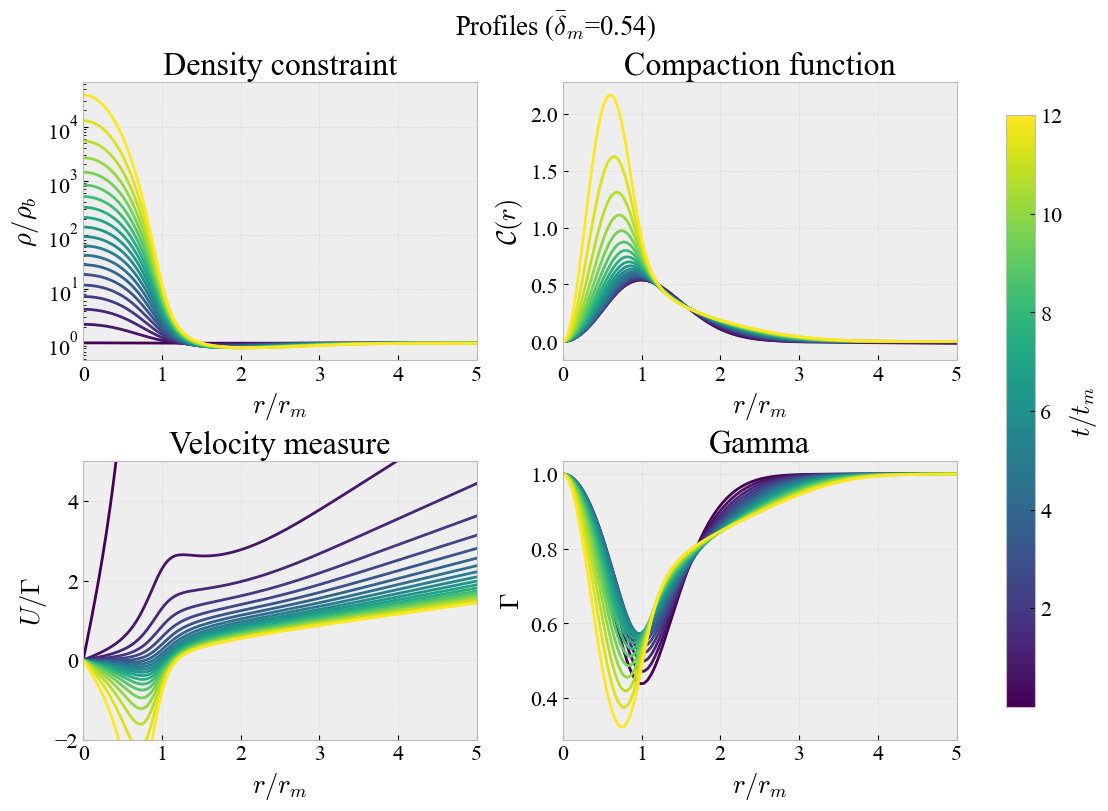

[0.5188373388275815, 0.5190492428058724, 0.5207843498122073, 0.5234776815830559, 0.52794770590651, 0.5347530957686629, 0.5429229352242898, 0.5538621564443107, 0.5676538199543077, 0.5838019985858951, 0.6054559459747462, 0.6305048779293719, 0.6645732108944579, 0.7061099030638596, 0.762130920714924, 0.8367951892499007, 0.9394119724769173, 1.0886157063425024, 1.321187609626801, 1.7205291097081652]


In [36]:
from matplotlib.animation import FuncAnimation, FFMpegWriter

def animate_compaction(snapshots, delta_bar_m, filename="compaction.mp4", duration=9):
    taus = sorted(snapshots.keys())
    nframes = len(taus)
    fps = nframes / duration   # enforce 9 second video

    fig, ax = plt.subplots(figsize=(7,5))
    line, = ax.plot([], [], lw=2, color='darkmagenta')
    time_text = ax.text(0.7, 0.9, "", transform=ax.transAxes)

    ax.set_xlim(0,5)
    ax.set_ylim(0, np.max([np.max(snapshots[t]["C"]) for t in taus])*1.2)
    ax.set_xlabel(r"$r/r_m$")
    ax.set_ylabel(r"$\mathcal{C}(r)$")
    ax.set_title(rf"Compaction evolution ($\bar\delta_m$={delta_bar_m})")
    ax.grid(True, alpha=0.3)

    def update(i):
        tau = taus[i]
        d = snapshots[tau]
        x = d["r_over_rm"]
        C = d["C"]

        order = np.argsort(x)
        line.set_data(x[order], C[order])
        time_text.set_text(f"t/tm = {tau:.3f}")
        return line, time_text

    anim = FuncAnimation(fig, update, frames=nframes, blit=True)

    writer = FFMpegWriter(fps=fps, bitrate=2000)
    anim.save(filename, writer=writer)
    print(f"Saved {filename} ({duration} s)")
    

"""
Reproducing Figs. 4-6 of:
Albert Escrivà, "Simulation of primordial black hole formation using pseudo-spectral methods"
Physics of the Dark Universe 27 (2020) 100466.
Each figure follows the same 4-panel structure:
Upper left: Analysis of the radius with the density
Upper Right: Analysis of radius with the Compaction Function
Lower Left: Analysis of radius with velocities (U and Gamma)
Lower Right: Analysis of radius with Gamma only

Each figure studies sub-critical, critical and super-critical, around the critical threshold, found numerically.

The formal spectral methods and numerics to determine the value of the critical threshold were taken directly from original SPriBHoS code,
with some notation and labelling changes. Original code has been labelled as such. Graphing code was not included in the published source,
therefore all plotting and graphic code should be assumed as original.

AI resources such as ChatGPT and CoPilot were used for troubleshooting and bug fixes.

"""

from __future__ import annotations
import math
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import seaborn as sns
cmap = sns.color_palette("viridis", as_cmap=True)
pi = math.pi

def chebymatrix(Ncheb,a,b):

	range_cheb = np.arange(0,Ncheb+1)
	x = np.cos(pi*range_cheb/Ncheb)
	t = (a+b)/2.-((a-b)/2.)*x
	carray = np.hstack([2, np.ones(Ncheb-1), 2])*(-1)**np.arange(0,Ncheb+1)
	X = np.tile(x,(Ncheb+1,1))
	dX = X.T - X
	Dp = (carray[:,np.newaxis]*(1.0/carray)[np.newaxis,:])/(dX+(np.identity(Ncheb+1)))       
	Dp = Dp - np.diag(Dp.sum(axis=1))            
	Dcheb =(2./(b-a))*Dp

	return Dcheb, t

def curvature_profile(xf,rmf):
	K = np.exp(-(xf/rmf)**2)
	return K

def derivative_curvature_profile(xf,rmf):
	Kd = -2.*(xf/rmf**2)*np.exp(-(xf/rmf)**2)
	return Kd


def A_versus_threshold_original_style(rm, w, delta_bar_m) :

    fw = 3.0 * (1.0 + w) / (5.0 + 3.0 * w)
    Krm = math.exp(-1.0)  # Gaussian Kbar(rm)=e^{-1}
    return delta_bar_m / (fw * Krm * (rm ** 2))


def A_versus_threshold_general(rm, w, delta_bar_m) :
    fw = 3.0 * (1.0 + w) / (5.0 + 3.0 * w)
    Kbar_rm = math.exp(-(1.0 ) * (1.0 ** (2.0 )))  
    return delta_bar_m / (fw * Kbar_rm * (rm ** 2))


@dataclass
class SimParams:
    w: float = 1.0 / 3.0
    t0: float = 1.0
    a0: float = 1.0
    Nh: int = 90
    rm_N: float = 10.0          
    dt0: float = 1e-3
    Ncheb: int = 200
    t_final: float = 80000      
    use_general_q: bool = False
   
C54_list=[]
# Same initial conditions, just defined as a class instead
class PBHSimulator:
    def __init__(self, p: SimParams):
        self.p = p
        self.alpha = 2.0 / (3.0 * (1.0 + p.w))  
        self.H0 = self.alpha / p.t0
        self.RH0 = 1.0 / self.H0
        self.eb0 = (3.0 / (8.0 * pi)) * (self.H0 ** 2)

        self.rmin = 0.0
        self.rmax = p.Nh * self.RH0

        # Chebyshev grid + D
        self.D, self.r = chebymatrix(p.Ncheb, self.rmin, self.rmax)
        self.ones = np.ones(p.Ncheb + 1, dtype=np.float64)

        #Previously defined within epsilon horizon crossing
        self.rm = p.rm_N * self.RH0
        self.tm = p.t0 * (p.rm_N ** 2)

  
    def energy_FRW(self, t) :
        return self.ones * self.eb0 * (self.p.t0 / t) ** 2

    def solution_FRW(self, t) :
        a = self.p.a0 * (t / self.p.t0) ** self.alpha   #scale factor
        H = self.alpha / t                              #Hubble Factor
        e = self.energy_FRW(t)                          #Energy density of the background
        R = a * self.r                                  #Areal Radius
        U = R * H                                       #Euler Velocity
        M = (4.0 * pi / 3.0) * e * R ** 3               #Mass of Background
        A = 1.0 * self.ones                             #Lapse Function
        G = 1.0 * self.ones                             #Gamma Function
        return e, R, U, M, A, G

    def initial_perturbation_magnitudes(self, K, Kp) :
        w = self.p.w
        dek = (3.0 * (1.0 + w) / (5.0 + 3.0 * w)) * (K + (self.r / 3.0) * Kp) * (self.rm ** 2)
        dUk = -(1.0 / (5.0 + 3.0 * w)) * K * (self.rm ** 2)
        dAk = -(w / (1.0 + w)) * dek
        dMk = -3.0 * (1.0 + w) * dUk
        dRk = -dek * w / ((1.0 + 3.0 * w) * (1.0 + w)) + dUk / (1.0 + 3.0 * w)
        return dek, dUk, dAk, dMk, dRk

    def epsilon_horizon_crossing(self):
        eps = 1.0 / (self.p.a0 * self.H0 * self.rm)
        tH = self.tm
        return eps, tH

    #called x_Ikk in source code
    def initial_conditions(self, eps, dek, dRk, dUk, dAk, dMk):
        eI = self.eb0 * (self.ones + dek * (eps ** 2))
        aI = self.p.a0
        RI = aI * self.r * (self.ones + dRk * (eps ** 2))
        UI = self.H0 * RI * (self.ones + dUk * (eps ** 2))
        AI = self.ones + dAk * (eps ** 2)
        MI = (4.0 * pi / 3.0) * self.eb0 * (self.ones + dMk * (eps ** 2)) * RI ** 3
        frac = MI[:-1] / RI[:-1]
        frac = np.insert(frac, len(frac), 0.0)
        GI = np.sqrt(self.ones + UI ** 2 - 2.0 * frac)
        return eI, RI, UI, AI, MI, GI

    def derivs(self, e, U, R) :
        de = np.dot(self.D,e)
        dU = np.dot(self.D,U)
        dR = np.dot(self.D,R)
        return de, dU, dR

    def system_static(self, e, M, R, U, eFRW):
        w = self.p.w
        A = (eFRW / e) ** (w / (w + 1.0))
        frac = M[:-1] / R[:-1]
        frac = np.insert(frac, len(frac), 0.0)

        arg = 1.0 + U**2 - 2.0 * frac

        # numerical guard: avoid tiny negative values from roundoff
        arg = np.maximum(arg, 0.0)

        G = np.sqrt(arg)
        return A, G

    #compiling excision functions from source code
    def RK_excision(self, U, R, M, A, G, e, de, dR, dU) :
        w = self.p.w
        frac = M[:-1] / (R[:-1] ** 2)
        frac = np.insert(frac, len(frac), 0.0)
        Ut = -A * (4.0 * pi * R * w * e + frac + (w / (1.0 + w)) * (de * G ** 2) / (e * dR))
        Rt = U * A
        Mt = -A * 4.0 * pi * w * e * U * (R ** 2)

        derU_R = dU / dR
        ratioUR = U[:-1] / R[:-1]
        ratioUR = np.insert(ratioUR, len(ratioUR), derU_R[-1])
        et = -A * e * (1.0 + w) * (2.0 * ratioUR + dU / dR)
        return Ut, Rt, Mt, et
    
    #compiling computation executing the solving, where stages represent different functions in source code
    def computation_excision(self, t, dt, U, R, M, A, G, e):
        # stage 1
        de1, dU1, dR1 = self.derivs(e, U, R)
        de1[0] = 0.0
        de1[-1] = 0.0
        k1U, k1R, k1M, k1e = self.RK_excision(U, R, M, A, G, e, de1, dR1, dU1)

        # stage 2
        e2 = e + 0.5 * dt * k1e
        U2 = U + 0.5 * dt * k1U
        R2 = R + 0.5 * dt * k1R
        M2 = M + 0.5 * dt * k1M
        U2[-1] = R2[-1] = M2[-1] = 0.0

        eFRW2 = self.energy_FRW(t + 0.5 * dt - dt)
        A2, G2 = self.system_static(e2, M2, R2, U2, eFRW2)
        de2, dU2, dR2 = self.derivs(e2, U2, R2)
        de2[0] = 0.0
        de2[-1] = 0.0
        k2U, k2R, k2M, k2e = self.RK_excision(U2, R2, M2, A2, G2, e2, de2, dR2, dU2)

        # stage 3
        e3 = e + 0.5 * dt * k2e
        U3 = U + 0.5 * dt * k2U
        R3 = R + 0.5 * dt * k2R
        M3 = M + 0.5 * dt * k2M
        U3[-1] = R3[-1] = M3[-1] = 0.0

        eFRW3 = self.energy_FRW(t + 0.5 * dt - dt)
        A3, G3 = self.system_static(e3, M3, R3, U3, eFRW3)
        de3, dU3, dR3 = self.derivs(e3, U3, R3)
        de3[0] = 0.0
        de3[-1] = 0.0
        k3U, k3R, k3M, k3e = self.RK_excision(U3, R3, M3, A3, G3, e3, de3, dR3, dU3)

        # stage 4
        e4 = e + dt * k3e
        U4 = U + dt * k3U
        R4 = R + dt * k3R
        M4 = M + dt * k3M
        U4[-1] = R4[-1] = M4[-1] = 0.0

        eFRW4 = self.energy_FRW(t + dt - dt)
        A4, G4 = self.system_static(e4, M4, R4, U4, eFRW4)
        de4, dU4, dR4 = self.derivs(e4, U4, R4)
        de4[0] = 0.0
        de4[-1] = 0.0
        k4U, k4R, k4M, k4e = self.RK_excision(U4, R4, M4, A4, G4, e4, de4, dR4, dU4)

        # combine
        Unew = U + (dt / 6.0) * (k1U + 2 * k2U + 2 * k3U + k4U)
        Rnew = R + (dt / 6.0) * (k1R + 2 * k2R + 2 * k3R + k4R)
        Mnew = M + (dt / 6.0) * (k1M + 2 * k2M + 2 * k3M + k4M)
        enew = e + (dt / 6.0) * (k1e + 2 * k2e + 2 * k3e + k4e)

        Unew[-1] = 0.0
        Rnew[-1] = 0.0
        Mnew[-1] = 0.0

        eFRW = self.energy_FRW(t + dt)
        Anew, Gnew = self.system_static(enew, Mnew, Rnew, Unew, eFRW)
        return Unew, Rnew, Mnew, enew, Anew, Gnew, eFRW

    #Redefined in a simpler way
    def compaction(self, M, R, eFRW ) :
        C = 2.0 * (M[:-1] - (4.0 / 3.0) * pi * eFRW[:-1] * (R[:-1] ** 3)) / R[:-1]
        
        C = np.insert(C, -1, 0.0)
        return C

    def build_initial_state(self, delta_bar_m) :
        eps, _ = self.epsilon_horizon_crossing()

      
        Kbar = curvature_profile(self.r, self.rm)
        Kbar_d = derivative_curvature_profile(self.r, self.rm)
        Aamp = A_versus_threshold_general(self.rm, self.p.w, delta_bar_m)
        
        K = Aamp * Kbar
        Kd = Aamp * Kbar_d

        dek, dUk, dAk, dMk, dRk = self.initial_perturbation_magnitudes(K, Kd)
        eI, RI, UI, AI, MI, GI = self.initial_conditions(eps, dek, dRk, dUk, dAk, dMk)
        return eI, RI, UI, AI, MI, GI
    #this involves original definitions for plotting purposes
    def evolve_snapshots(self, delta_bar_m, snapshot_times_over_tm,t_stop_over_tm: Optional[float] = None):
      
        e, R, U, A, M, G = self.build_initial_state(delta_bar_m)
        t = self.p.t0

        snapshot_times_over_tm = sorted(snapshot_times_over_tm)
        targets = [tau * self.tm for tau in snapshot_times_over_tm]
        target_idx = 0

        out: Dict[float, Dict[str, np.ndarray]] = {}
        eps, tH = self.epsilon_horizon_crossing()

        # stop time
        if t_stop_over_tm is None:
            t_stop = targets[-1]
        else:
            t_stop = t_stop_over_tm * self.tm

        # main loop
        while t < t_stop and target_idx < len(targets):
            dt = self.p.dt0 * math.sqrt(t)
            t_next = t + dt

            U, R, M, e, A, G, eFRW = self.computation_excision(t, dt, U, R, M, A, G, e)
            t = t_next

            while target_idx < len(targets) and t >= targets[target_idx]:
              
                tau = snapshot_times_over_tm[target_idx]

                # quantities used in Figs 4–6 
                # rho/rho_b
                rho_ratio = e / eFRW

                # compaction C
                C = self.compaction(M, R, eFRW)
                C54_list.append(max(C))
                Gamma = G.copy()

                # U/Gamma 
                with np.errstate(divide="ignore", invalid="ignore"):
                    U_over_Gamma = np.where(Gamma != 0.0, U / Gamma, 0.0)

                # store
                r_over_rm = self.r / self.rm

                out[tau] = {
                    "r": self.r.copy(),
                    "rm": np.array([self.rm], dtype=float),
                    "r_over_rm": r_over_rm.copy(),

                    "R": R.copy(),
                    "U": U.copy(),
                    "M": M.copy(),
                    "A": A.copy(),
                    "Gamma": Gamma,
                    "rho": e.copy(),
                    "rho_FRW": eFRW.copy(),
                    "rho_ratio": rho_ratio,
                    "C": C,
                    "U_over_Gamma": U_over_Gamma,
                    "t": np.array([t], dtype=float),
                    "t_over_tm": np.array([t / self.tm], dtype=float),
                    }


                target_idx += 1

        return out


def _paper_axes_style(ax: plt.Axes, xlabel, ylabel, title):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.grid(True, alpha=0.3)

def plot_fig4_profiles(
    snapshots,
    *,
    delta_bar_m,
    savepath: Optional[str] = None,
):

    taus = sorted(snapshots.keys())

    fig, axs = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

    norm = plt.Normalize(vmin=min(taus), vmax=max(taus))

    for tau in taus:
        d = snapshots[tau]
        x = d["r_over_rm"]
        order = np.argsort(x)
        x = x[order]

        color = cmap(norm(tau))   # color by time

        axs[0, 0].semilogy(x, d["rho_ratio"][order], color=color)
        axs[0, 1].plot(x, d["C"][order], color=color)
        axs[1, 0].plot(x, d["U_over_Gamma"][order], color=color)
        axs[1, 1].plot(x, d["Gamma"][order], color=color)

        for ax in axs.flat:
            ax.set_xlim(0,5)
        axs[1,0].set_ylim(-2, 5)

    _paper_axes_style(axs[0, 0], r"$r/r_m$", r"$\rho/\rho_b$", "Density constraint")
    _paper_axes_style(axs[0, 1], r"$r/r_m$", r"$\mathcal{C}(r)$", "Compaction function")
    _paper_axes_style(axs[1, 0], r"$r/r_m$", r"$U/\Gamma$", "Velocity measure")
    _paper_axes_style(axs[1, 1], r"$r/r_m$", r"$\Gamma$", r"Gamma")

    # Add colorbar 
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axs, shrink=0.9)
    cbar.set_label(r"$t/t_m$")

    fig.suptitle(rf"Profiles ($\bar\delta_m$={delta_bar_m})")

    if savepath:
        fig.savefig(savepath, dpi=200)
    plt.show()

def main():
    p = SimParams(
        w=1.0 / 3.0,
        t0=1.0,
        a0=1.0,
        Nh=90,
        rm_N=10.0,
        dt0=1e-3,
        Ncheb=200,          # paper uses high N for these figs
        t_final=8.0e4,
        use_general_q=False,
   
    
    )

    sim = PBHSimulator(p)
  
    delta_vals = [0.54]

    # Snapshot times t/tm
    snapshot_taus = np.linspace(0.0001,12,20)

    for delta_bar_m in delta_vals:
       
        snaps = sim.evolve_snapshots(delta_bar_m=delta_bar_m, snapshot_times_over_tm=snapshot_taus)
        plot_fig4_profiles(snaps, delta_bar_m=delta_bar_m)

if __name__ == "__main__":
    main()

print(C52_list)


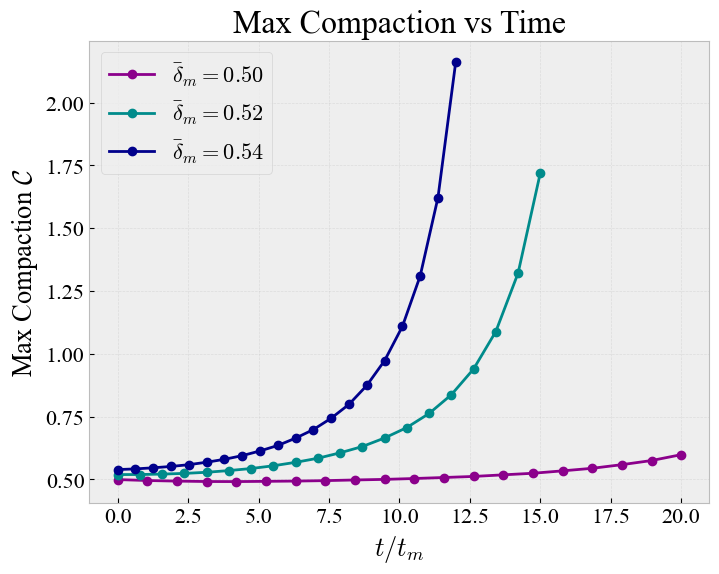

In [37]:

plt.rcParams.update({'font.size': 16})
plt.rcParams["font.family"] = "Times New Roman"
plt.style.use('bmh')

plt.figure(figsize=(8, 6))
plt.plot(np.linspace(0.0001,20,20),C_list, marker='o', color='darkmagenta')
plt.plot(np.linspace(0.0001,15,20),C52_list, marker='o', color='darkcyan')
plt.plot(np.linspace(0.0001,12,20),C54_list, marker='o', color='darkblue')
plt.legend([r"$\bar\delta_m=0.50$", r"$\bar\delta_m=0.52$", r"$\bar\delta_m=0.54$"])
plt.xlabel(r"$t/t_m$")
plt.ylabel(r"Max Compaction $\mathcal{C}$")
plt.title("Max Compaction vs Time")
plt.grid(True, alpha=0.3)
plt.savefig("compaction_plot.pdf", format="pdf", bbox_inches='tight')
plt.show()

C0(delta) coefficients: [-12.83875   15.184425  -3.890798]
B(delta) coefficients: [-0.0675    0.1056   -0.034724]
lambda(delta) coefficients: [-118.81125   131.244775  -35.694677]


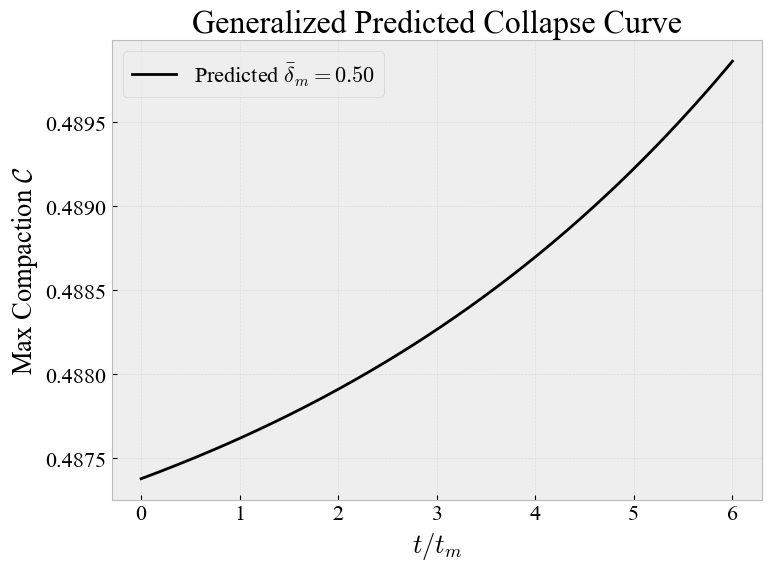

In [40]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 16})
plt.rcParams["font.family"] = "Times New Roman"
plt.style.use('bmh')

#test delta data
delta_data = np.array([0.50, 0.52, 0.54])

C0_data = np.array([0.491727, 0.533505, 0.565012])
B_data  = np.array([0.001201, 0.001936, 0.002617])
lam_data = np.array([0.224898, 0.426044, 0.532141])

#fit parameter in delta, exact for 3 points, but gives a formula for any delta in the range,
# AI was used to determine the best fitting method and to implement it, but the actual fitting was done by hand and verified graphically
coef_C0  = np.polyfit(delta_data, C0_data, 2)
coef_B   = np.polyfit(delta_data, B_data, 2)
coef_lam = np.polyfit(delta_data, lam_data, 2)

def C0_of_delta(delta):
    return np.polyval(coef_C0, delta)

def B_of_delta(delta):
    return np.polyval(coef_B, delta)

def lam_of_delta(delta):
    return np.polyval(coef_lam, delta)

#to generalise the formula for any delta, we can use the fitted parameters to predict C0, B and lambda, and then use those in the original formula
def C_model(t, delta):
    C0 = C0_of_delta(delta)
    B = B_of_delta(delta)
    lam = lam_of_delta(delta)
    return C0 + B * (np.exp(lam * t))

#print the fitted coefficients for reference
print("C0(delta) coefficients:", coef_C0)
print("B(delta) coefficients:", coef_B)
print("lambda(delta) coefficients:", coef_lam)

#an example of using the model to predict the compaction curve for a new delta value
delta_new = 0.4977
t = np.linspace(0, 6, 300)
C_pred = C_model(t, delta_new)

plt.figure(figsize=(8, 6))
plt.plot(t, C_pred, color='black', lw=2, label=rf"Predicted $\bar{{\delta}}_m={delta_new:.2f}$")
plt.xlabel(r"$t/t_m$")
plt.ylabel(r"Max Compaction $\mathcal{C}$")
plt.title("Generalized Predicted Collapse Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

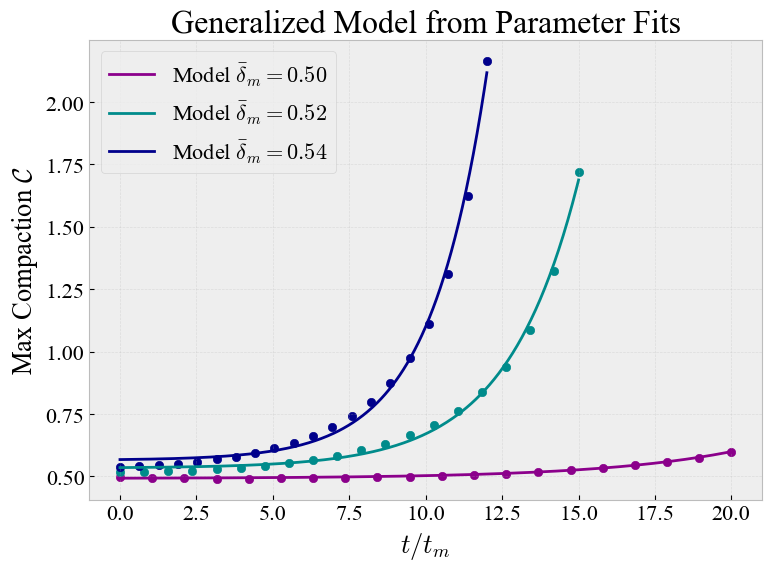

In [41]:
t50 = np.linspace(0.0001, 20, 300)
t52 = np.linspace(0.0001, 15, 300)
t54 = np.linspace(0.0001, 12, 300)

plt.figure(figsize=(8, 6))
plt.plot(t50, C_model(t50, 0.50), label=r"Model $\bar{\delta}_m=0.50$", color="darkmagenta")
plt.plot(t52, C_model(t52, 0.52), label=r"Model $\bar{\delta}_m=0.52$", color="darkcyan")
plt.plot(t54, C_model(t54, 0.54), label=r"Model $\bar{\delta}_m=0.54$", color="darkblue")
plt.scatter(np.linspace(0.0001,20,20),C_list, marker='o', color='darkmagenta')
plt.scatter(np.linspace(0.0001,15,20),C52_list, marker='o', color='darkcyan')
plt.scatter(np.linspace(0.0001,12,20),C54_list, marker='o', color='darkblue')
plt.xlabel(r"$t/t_m$")
plt.ylabel(r"Max Compaction $\mathcal{C}$")
plt.title("Generalized Model from Parameter Fits")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("gen_compaction_plot.pdf", format="pdf", bbox_inches='tight')
plt.show()